<a href="https://colab.research.google.com/github/antonellagambarte/proyecto-final-CEIA/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import math
# from ydata_profiling import ProfileReport

DATASET: heart-disease from kaggle

https://www.kaggle.com/datasets/oktayrdeki/heart-disease/data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Proyecto final EIA 2025/codigo/proyecto-final-EIA/datasets/heart_disease.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.shape

(10000, 21)

El dataset cuenta con 21 variables, muchas de las cuales fueron identificadas durante la fase investigativa como posibles factores de riesgo para enfermedades cardiovasculares.

Contiene un total de 10,000 registros, una cantidad suficiente para llevar a cabo un análisis exploratorio significativo.


### **Descripción de variables**

- Age: La edad del individuo. +

- Gender: El género del individuo (Masculino o Femenino). +

- Blood Pressure: La presión arterial del individuo (sistólica). +

- Cholesterol Level: El nivel total de colesterol del individuo. +

- Exercise Habits: Los hábitos de ejercicio del individuo (Bajo, Medio, Alto). +

- Smoking: Si el individuo fuma o no (Sí o No). +

- Family Heart Disease: Si hay antecedentes familiares de enfermedad cardíaca (Sí o No). +

- Diabetes: Si el individuo tiene diabetes (Sí o No). +

- BMI: El índice de masa corporal del individuo.

- High Blood Pressure: Si el individuo tiene presión arterial alta (Sí o No).

- Low HDL Cholesterol: Si el individuo tiene colesterol HDL bajo (Sí o No). +

- High LDL Cholesterol: Si el individuo tiene colesterol LDL alto (Sí o No). +

- Alcohol Consumption: El nivel de consumo de alcohol del individuo (Ninguno, Bajo, Medio, Alto). +

- Stress Level: El nivel de estrés del individuo (Bajo, Medio, Alto).

- Sleep Hours: La cantidad de horas que duerme el individuo. +

- Sugar Consumption: El nivel de consumo de azúcar del individuo (Bajo, Medio, Alto).

- Triglyceride Level: El nivel de triglicéridos del individuo. +

- Fasting Blood Sugar: El nivel de glucosa en sangre en ayunas del individuo.

- CRP Level: El nivel de proteína C reactiva (un marcador de inflamación).

- Homocysteine Level: El nivel de homocisteína del individuo (un aminoácido que afecta la salud de los vasos sanguíneos).

- Heart Disease Status: El estado de la enfermedad cardíaca del individuo (Sí o No).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

### **Ajuste de tipos**

In [ ]:
df['Gender'] = df['Gender'].astype('category')
df['Exercise Habits'] = df['Exercise Habits'].astype('category')
df['Smoking'] = df['Smoking'].astype('category')
df['Family Heart Disease'] = df['Family Heart Disease'].astype('category')
df['Diabetes'] = df['Diabetes'].astype('category')
df['High Blood Pressure'] = df['High Blood Pressure'].astype('category')
df['Low HDL Cholesterol'] = df['Low HDL Cholesterol'].astype('category')
df['High LDL Cholesterol'] = df['High LDL Cholesterol'].astype('category')
df['Alcohol Consumption'] = df['Alcohol Consumption'].astype('category')
df['Stress Level'] = df['Stress Level'].astype('category')
df['Sugar Consumption'] = df['Sugar Consumption'].astype('category')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Age                   9971 non-null   float64 
 1   Gender                9981 non-null   category
 2   Blood Pressure        9981 non-null   float64 
 3   Cholesterol Level     9970 non-null   float64 
 4   Exercise Habits       9975 non-null   category
 5   Smoking               9975 non-null   category
 6   Family Heart Disease  9979 non-null   category
 7   Diabetes              9970 non-null   category
 8   BMI                   9978 non-null   float64 
 9   High Blood Pressure   9974 non-null   category
 10  Low HDL Cholesterol   9975 non-null   category
 11  High LDL Cholesterol  9974 non-null   category
 12  Alcohol Consumption   7414 non-null   category
 13  Stress Level          9978 non-null   category
 14  Sleep Hours           9975 non-null   float64 
 15  Sug

#### **Control de valores**

Compruebo si existen filas duplicadas

In [ ]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 0


#### **Análisis de valores faltantes**

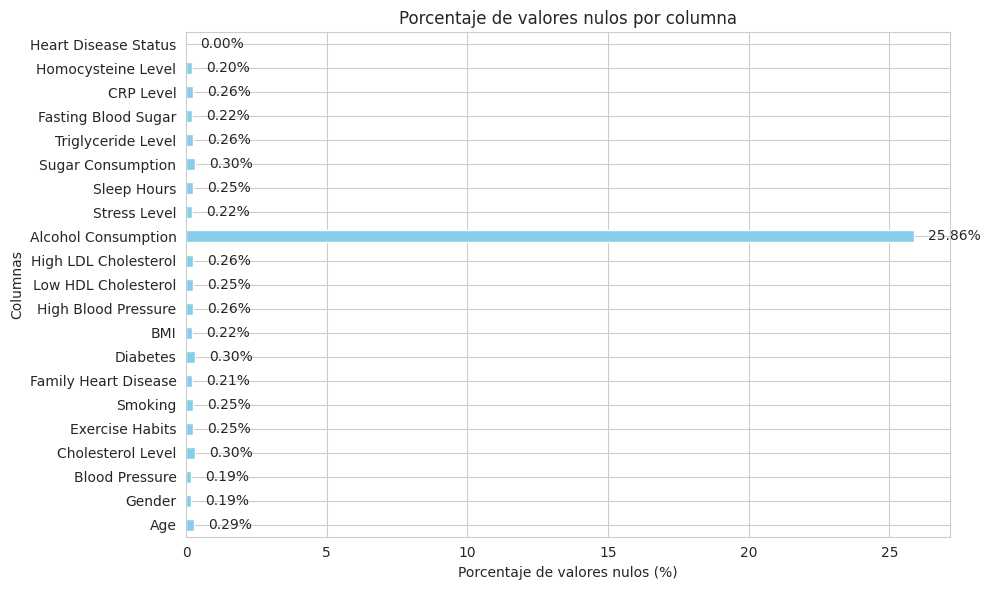

In [ ]:
porcentaje_nulos = df.isna().mean().round(4) * 100

plt.figure(figsize=(10, 6))
porcentaje_nulos.plot(kind='barh', color='skyblue')

plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Porcentaje de valores nulos (%)')
plt.ylabel('Columnas')

for index, value in enumerate(porcentaje_nulos):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

plt.tight_layout()
plt.show()

Se observan valores faltantes en todas las variables excepto en la variable target Heart Disease Status. La variable Alcohol Consumption es la que presenta mayor porcentaje de faltates con un 25,86%. Si bien es alto, no es tanto como para descartar dicha columna.

Más adelante, se analizará como tratar los valores faltantes en estas columnas.

#### **Matriz de valores faltantes**


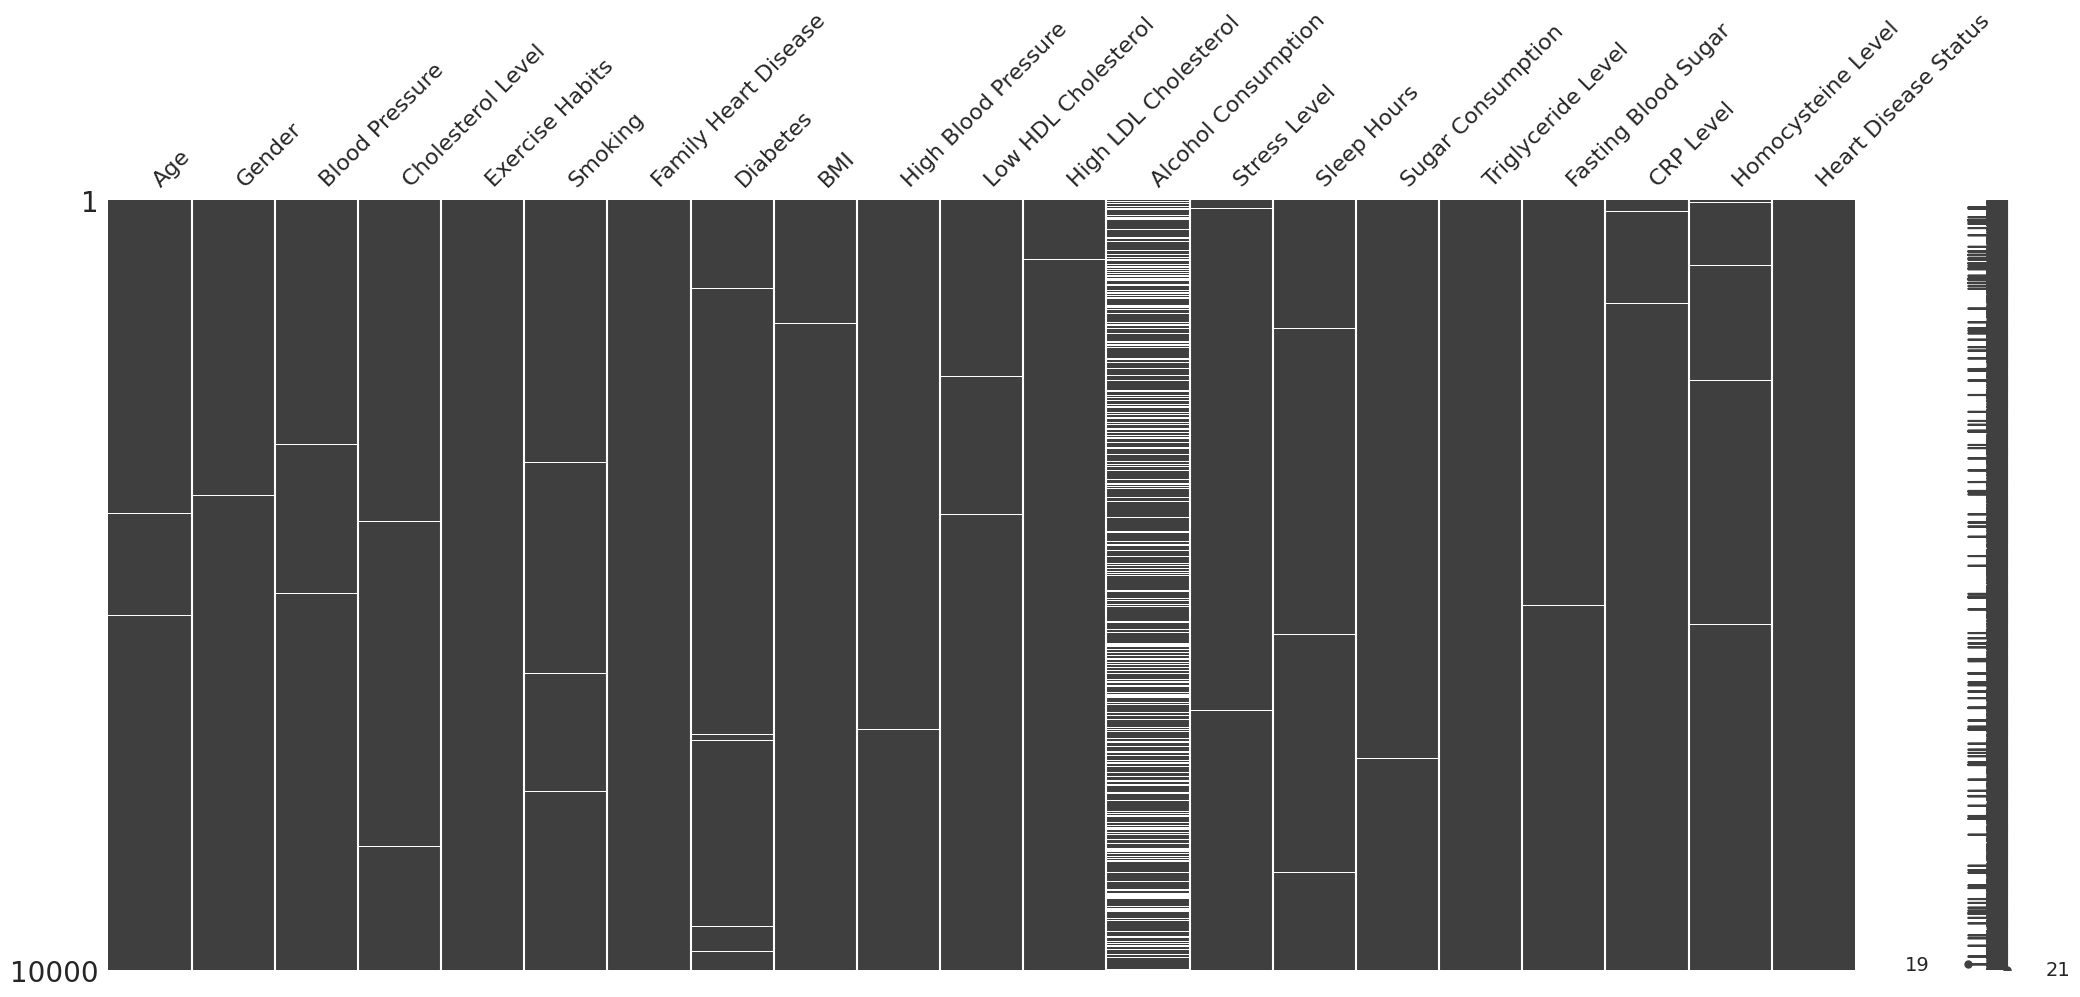

In [ ]:
msno.matrix(df)
plt.show()

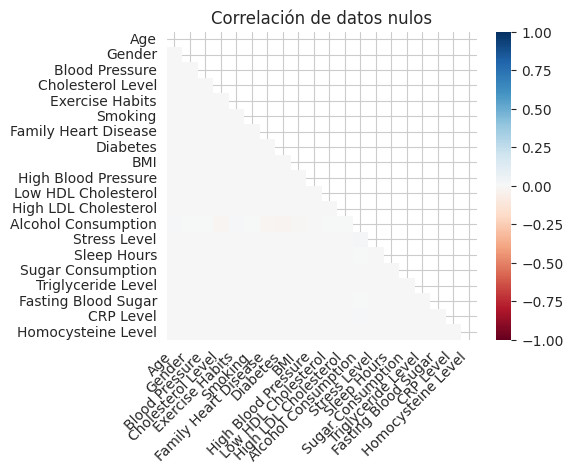

In [ ]:
msno.heatmap(df, fontsize=10, figsize=(5,4))
plt.title("Correlación de datos nulos", fontsize=12)
plt.show()

Luego de observar la matriz de datos faltantes y el mapa de calor se concluye que no hay relación significativa entre los valores nulos de las columnas

### **Faltantes de Alcohol Consumption**

In [ ]:
# num_cols = df.select_dtypes(include=['float', 'int']).columns

# for col in num_cols:
#     sns.boxplot(data=df, x='is_missing', y=col)
#     plt.title(f'{col} según si falta Alcohol Consumption')
#     plt.show()


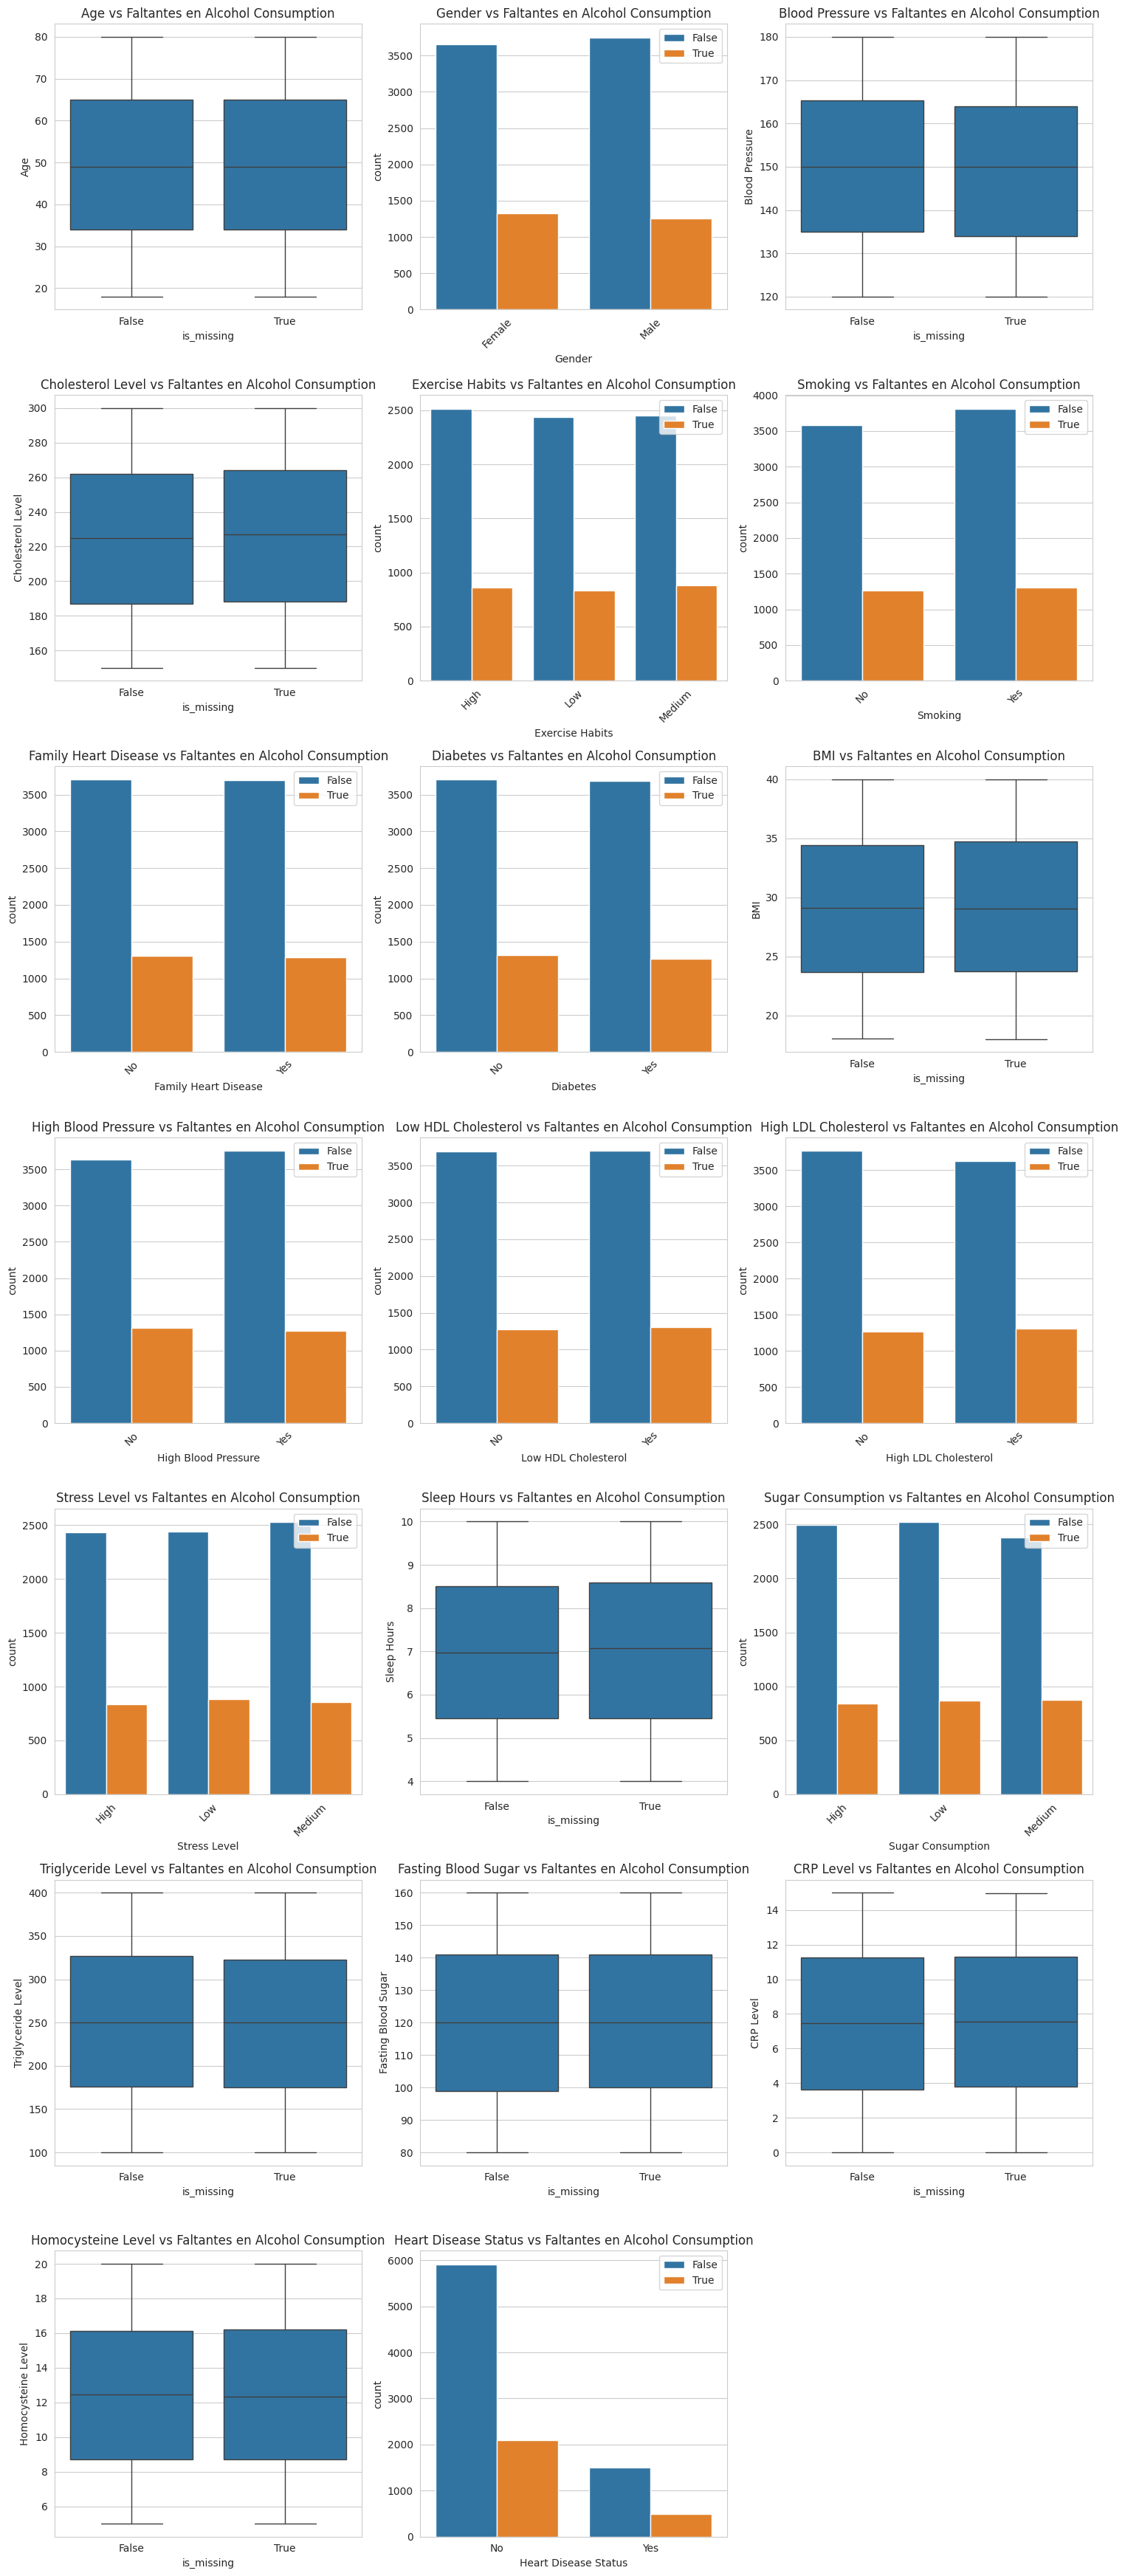

In [ ]:
col = 'Alcohol Consumption'
df['is_missing'] = df[col].isnull()

variables_a_probar = ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking',
                      'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol',
                      'High LDL Cholesterol', 'Stress Level', 'Sleep Hours', 'Sugar Consumption',
                      'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

n = len(variables_a_probar)
cols = 3
rows = n // cols + (n % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))

for i, var in enumerate(variables_a_probar):
    ax = axes[i // cols, i % cols]
    if df[var].dtype.name in ['category', 'object']:
        sns.countplot(data=df, x=var, hue='is_missing', ax=ax)
        ax.legend(loc='upper right')
    else:
        sns.boxplot(data=df, x='is_missing', y=var, ax=ax)
    ax.set_title(f'{var} vs Faltantes en Alcohol Consumption')
    if var in ['Smoking', 'Exercise Habits', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
               'High LDL Cholesterol', 'Stress Level', 'Sugar Consumption', 'Gender']:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

# Remover ejes vacíos si los hay
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.tight_layout()
plt.show()


porcentajes diferentes claros con respecto al target. MAR respeccto al target

### **resto de faltantes**

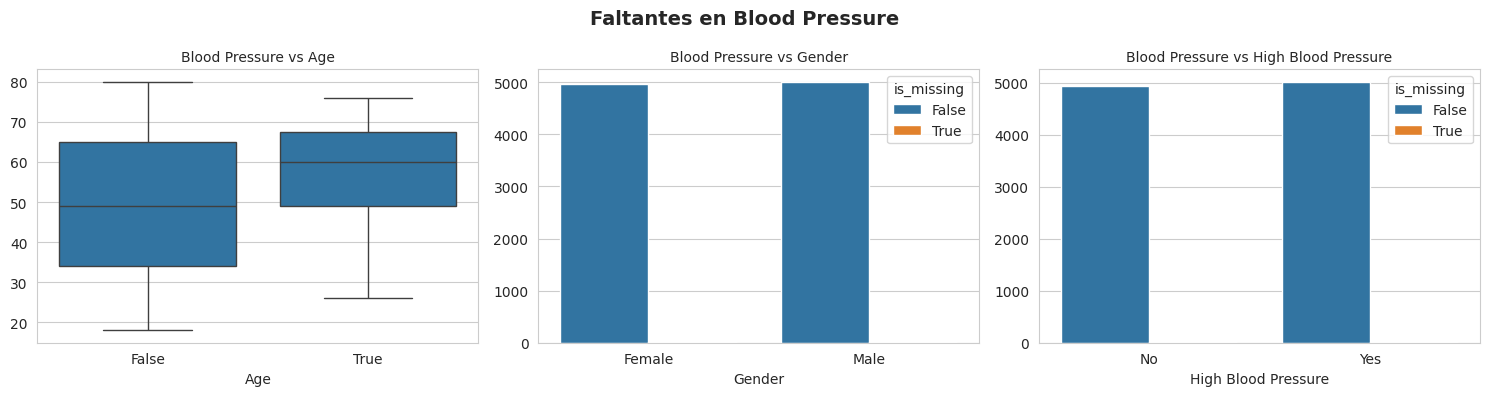

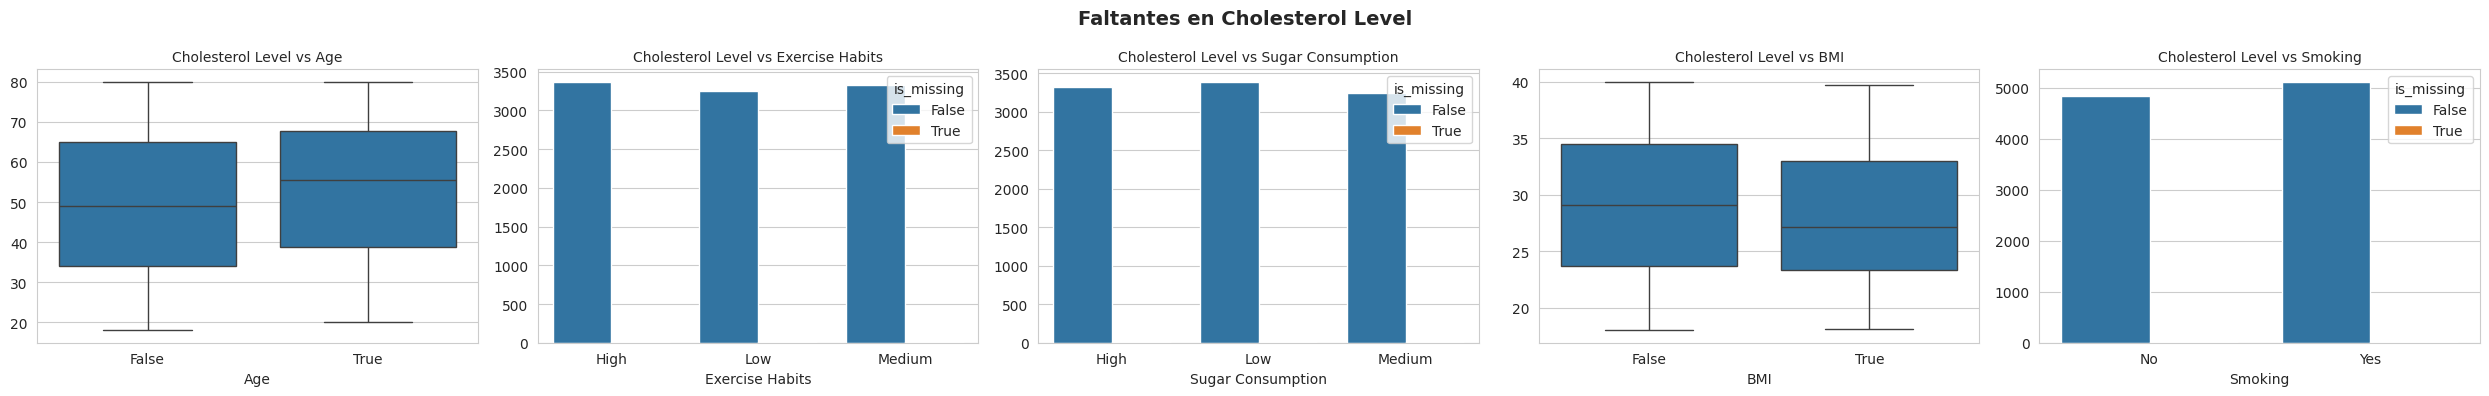

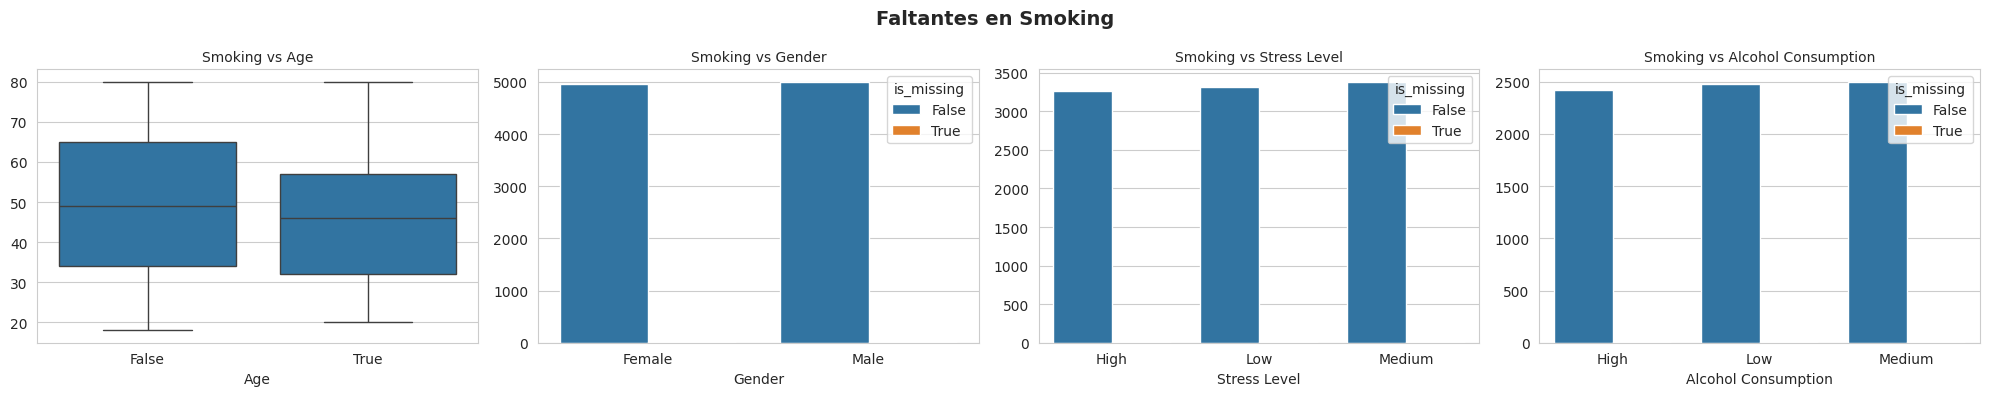

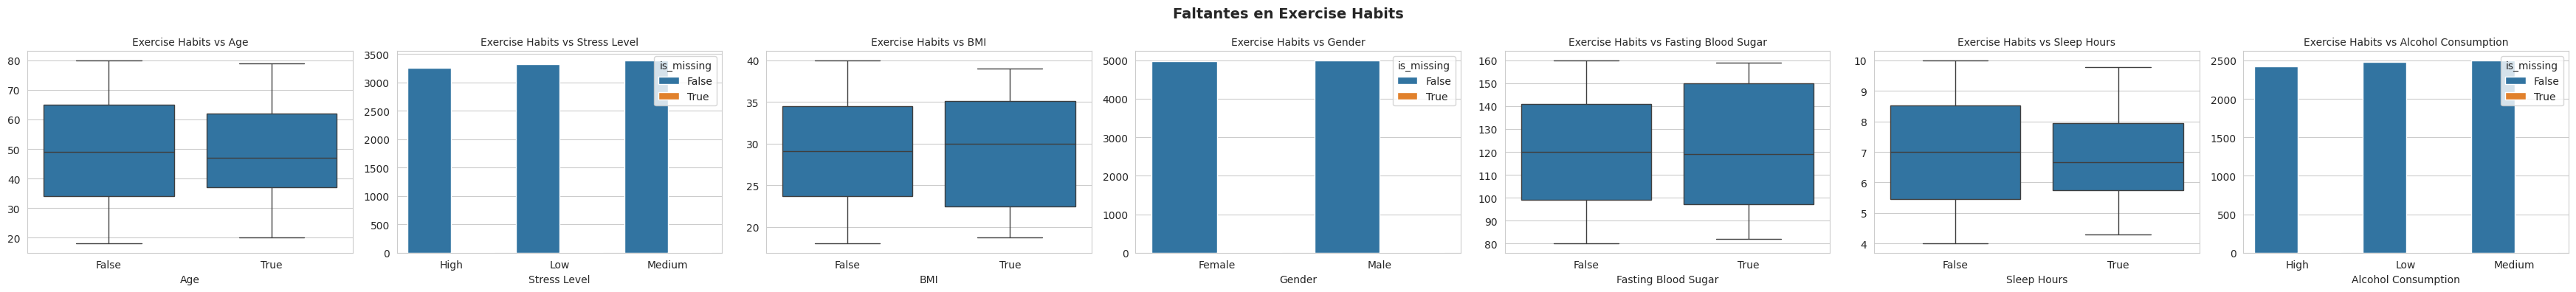

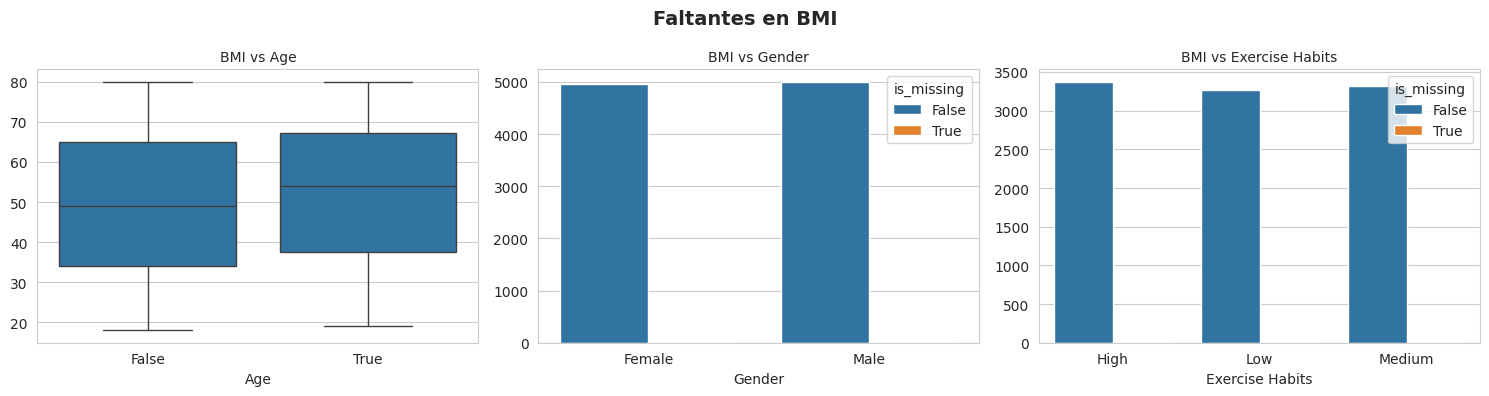

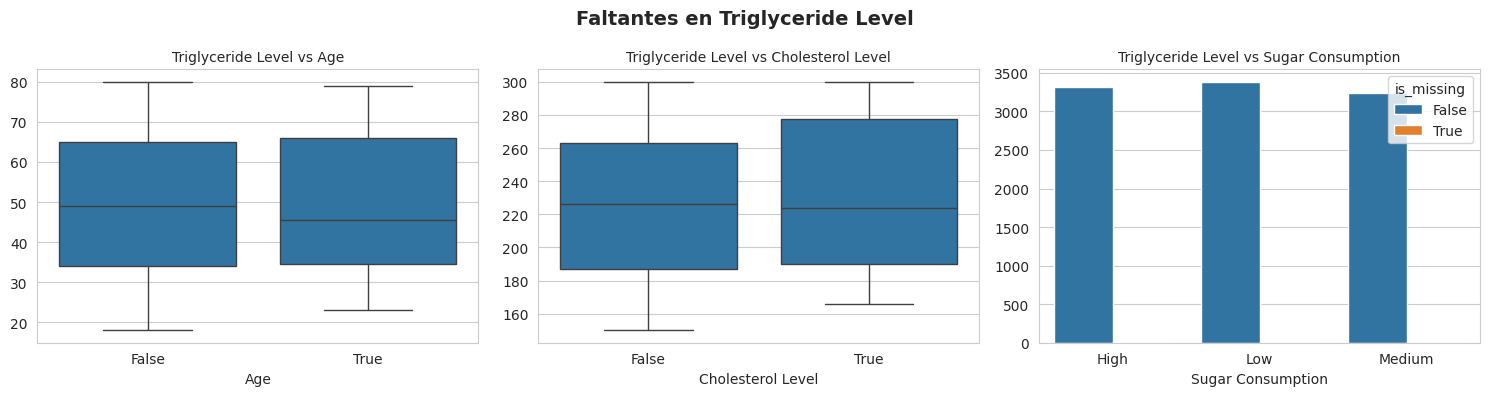

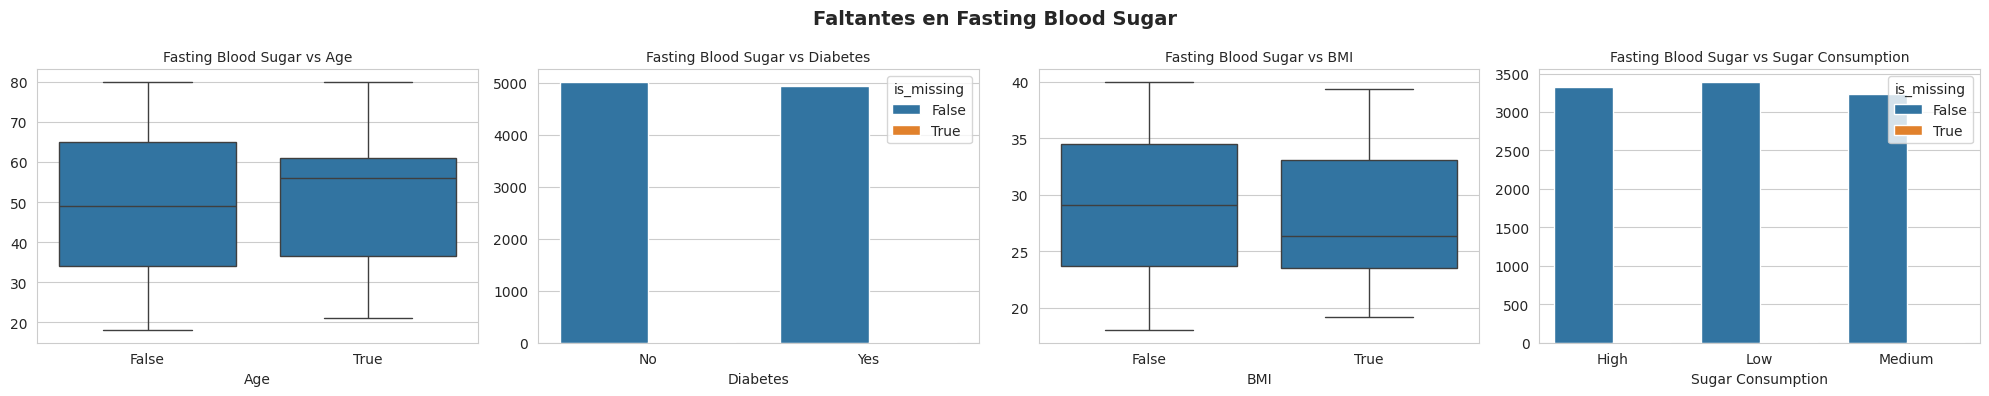

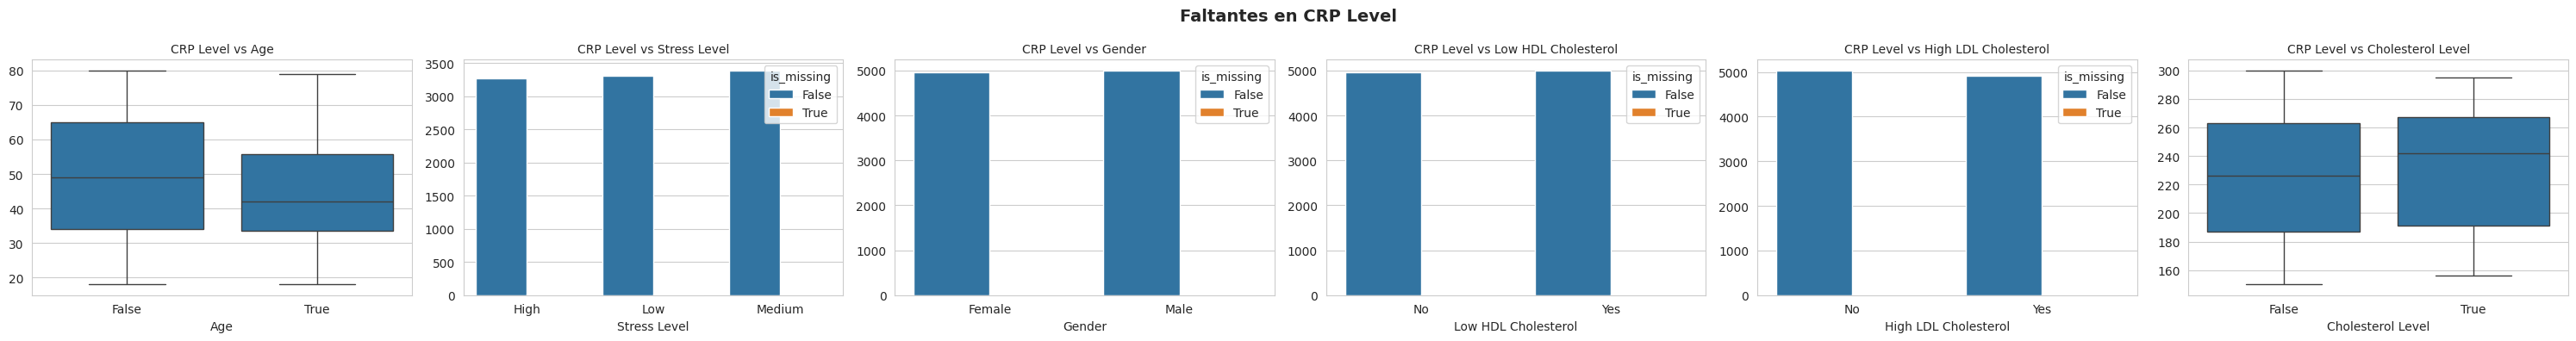

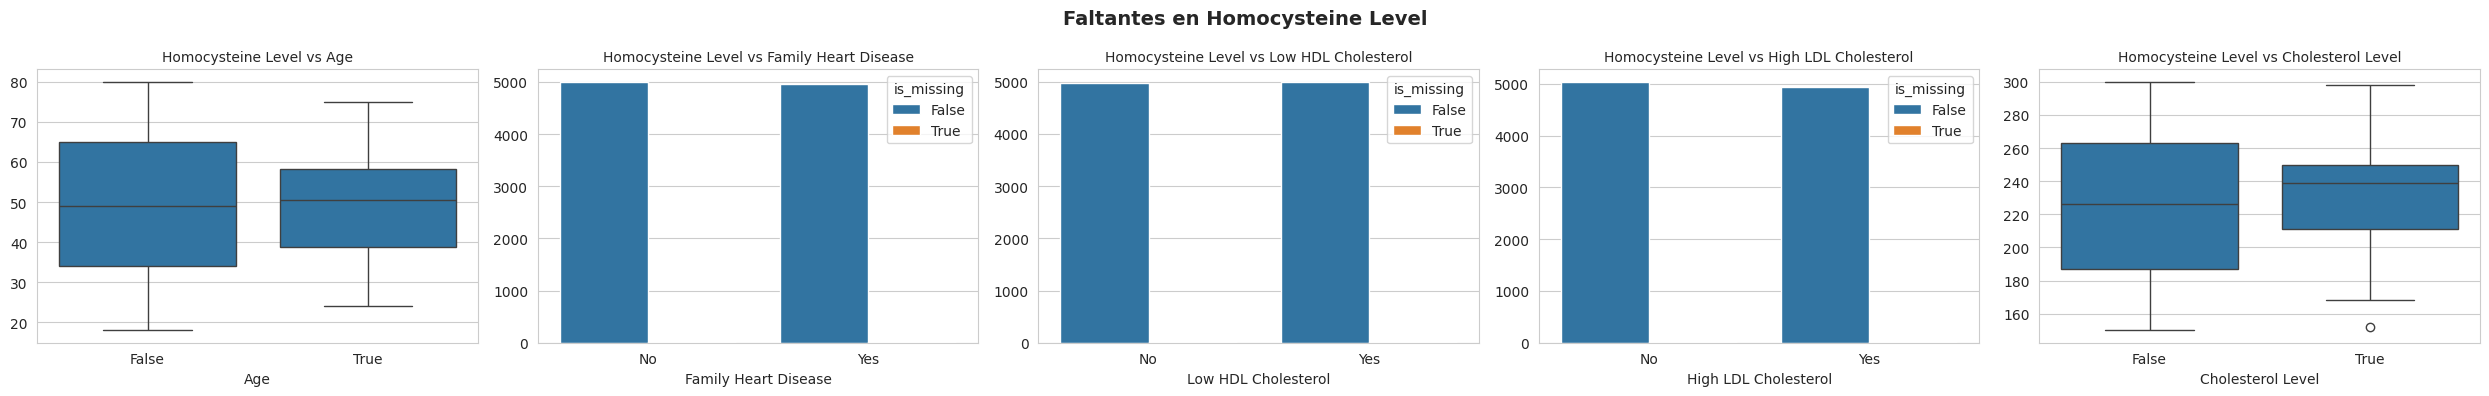

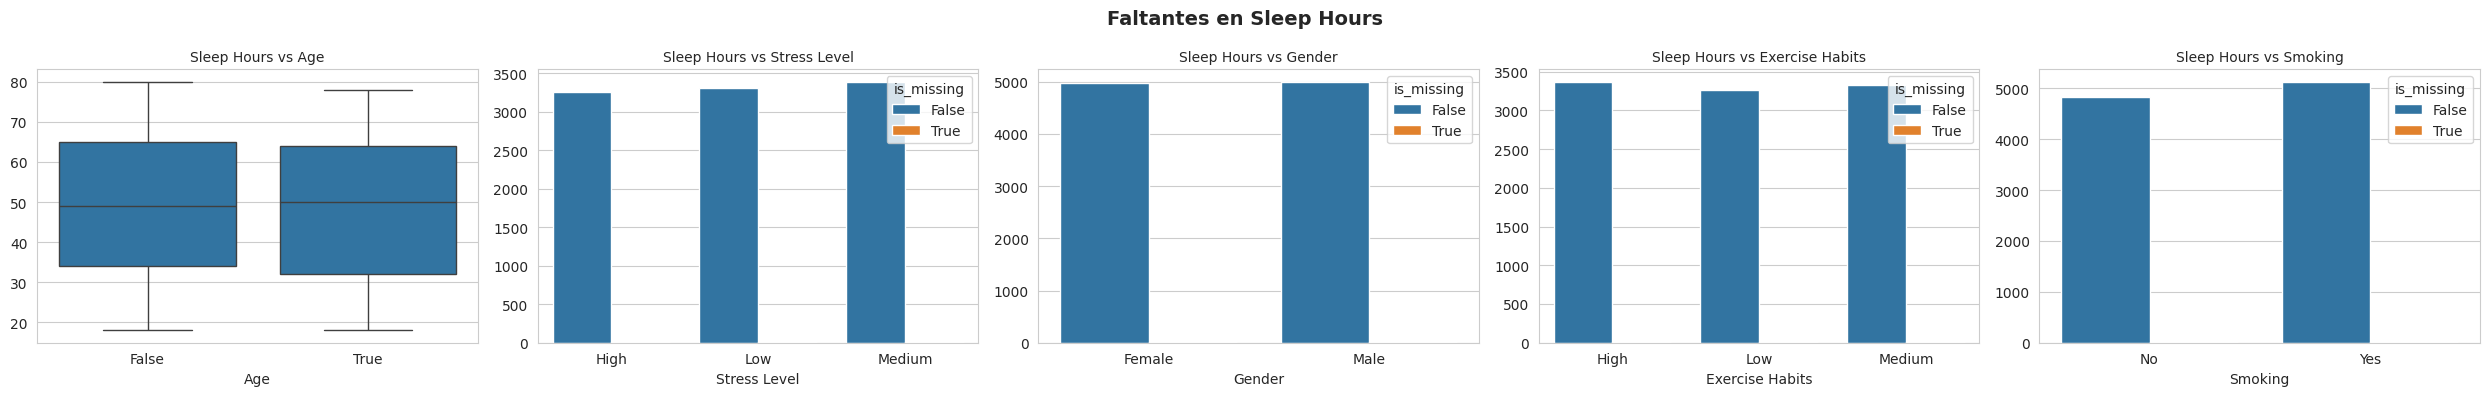

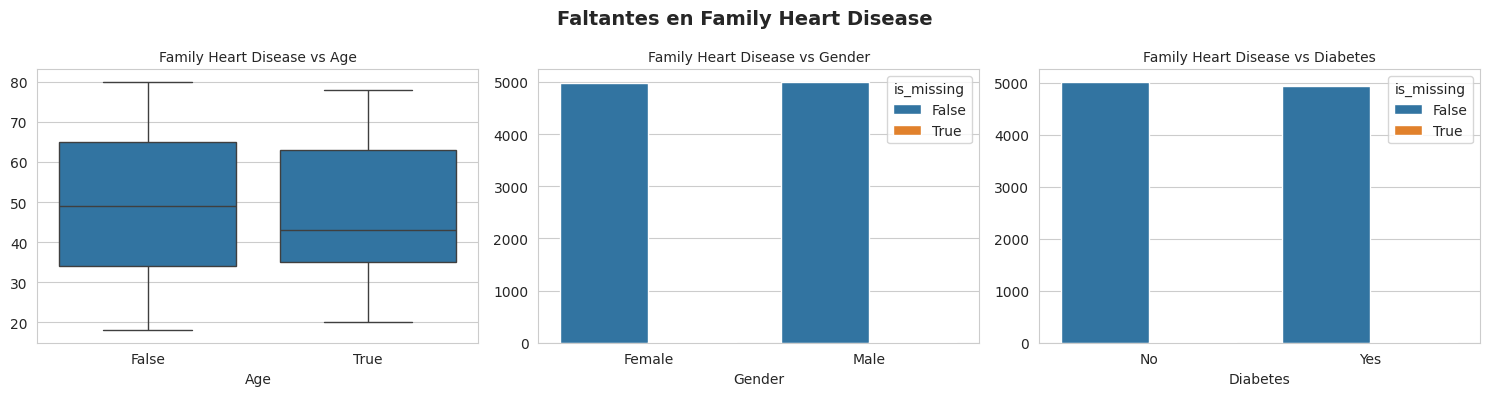

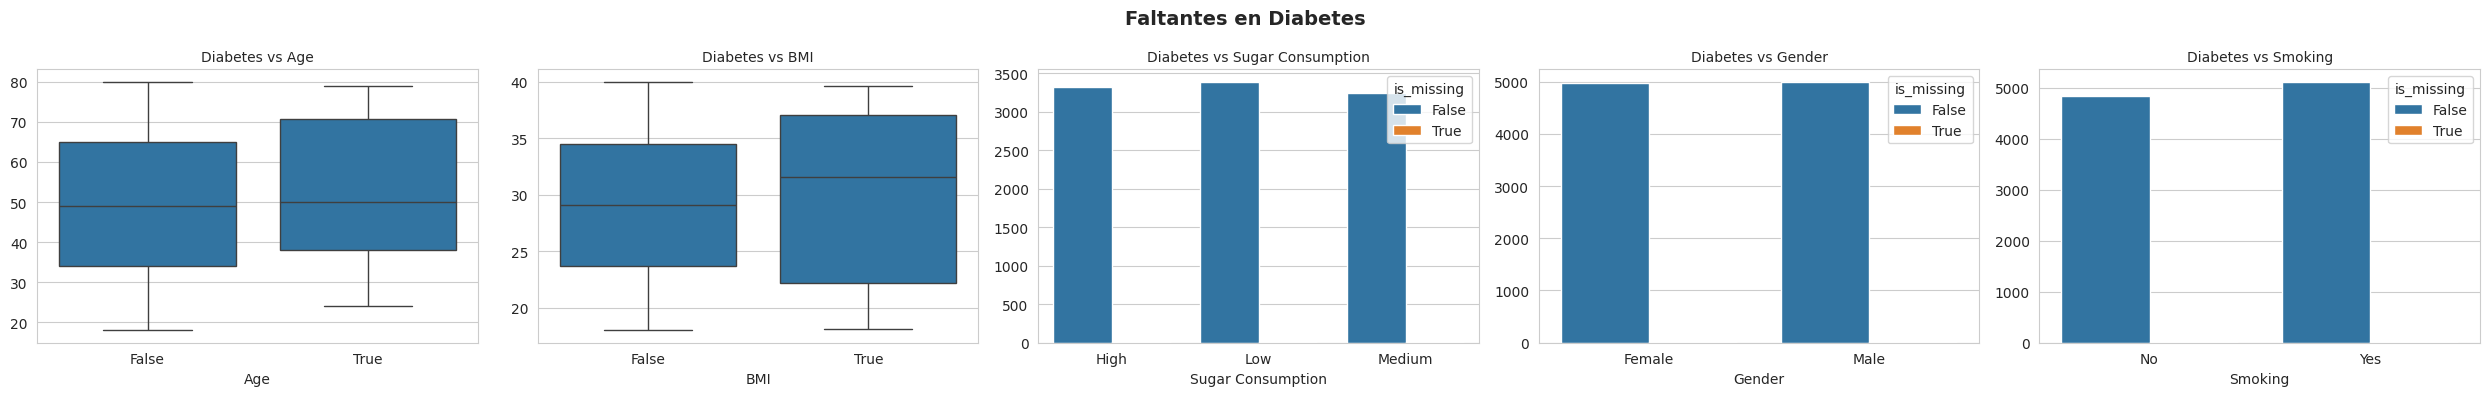

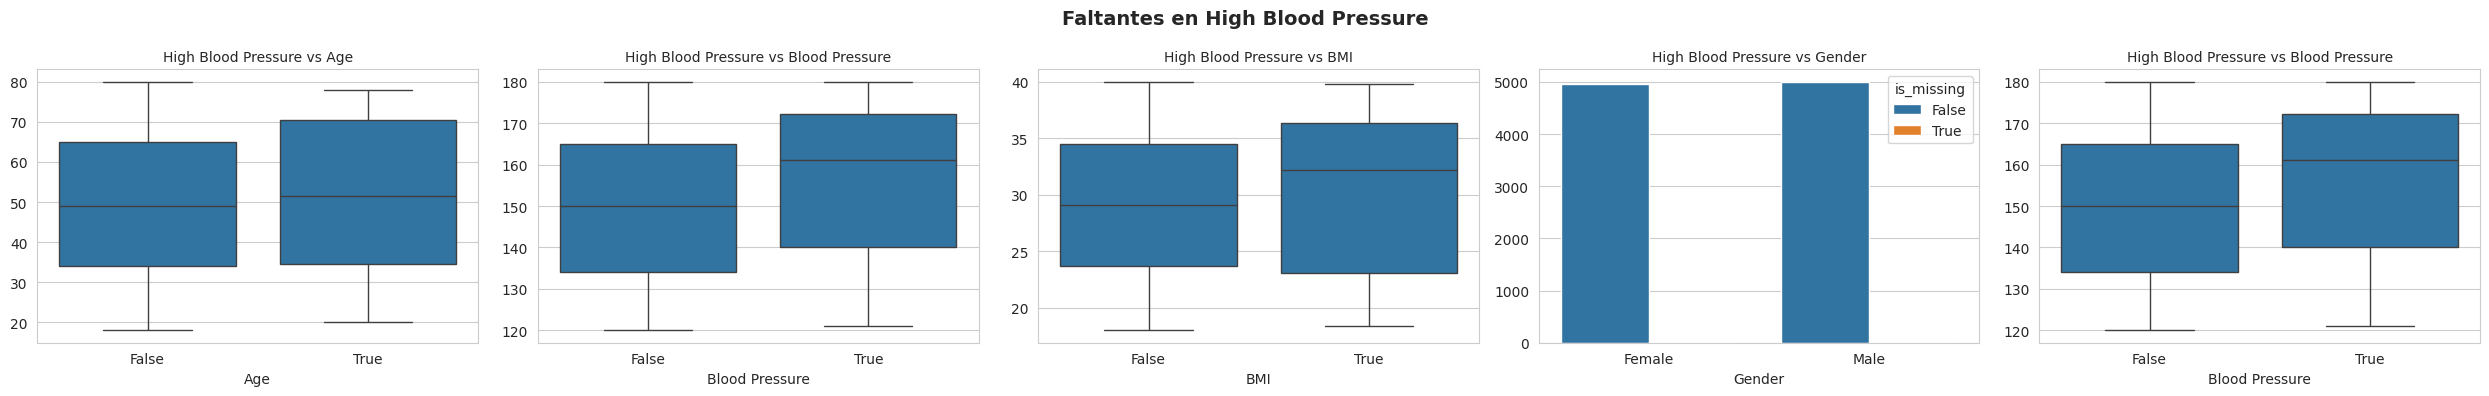

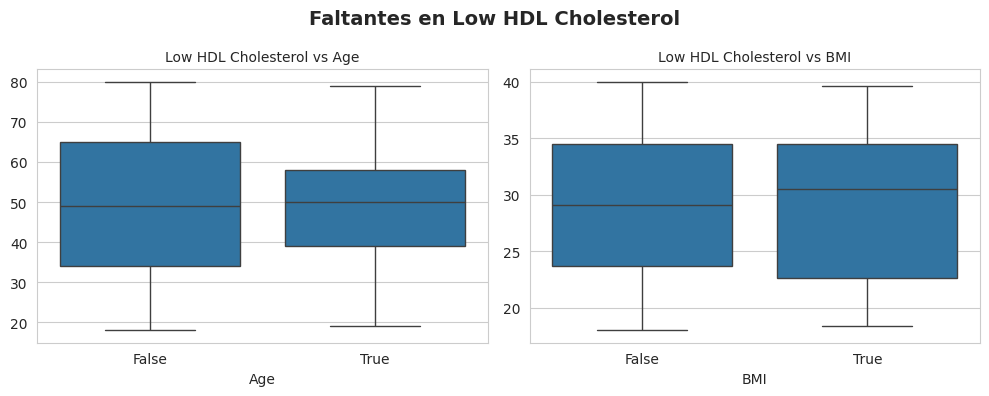

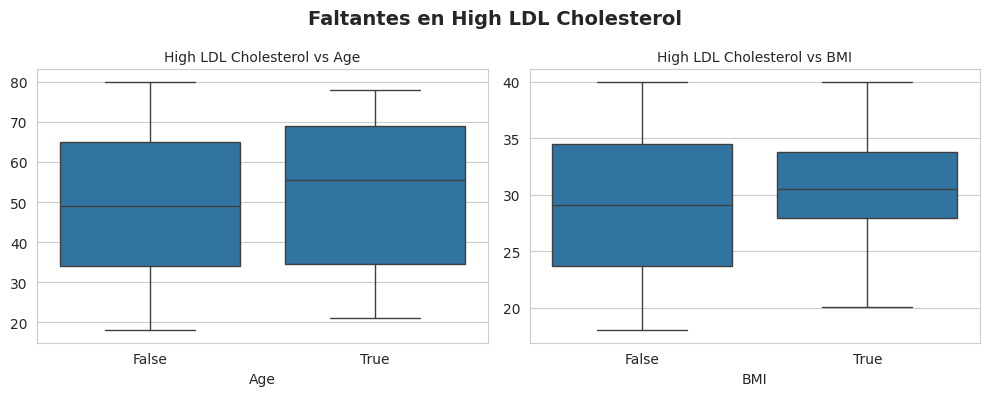

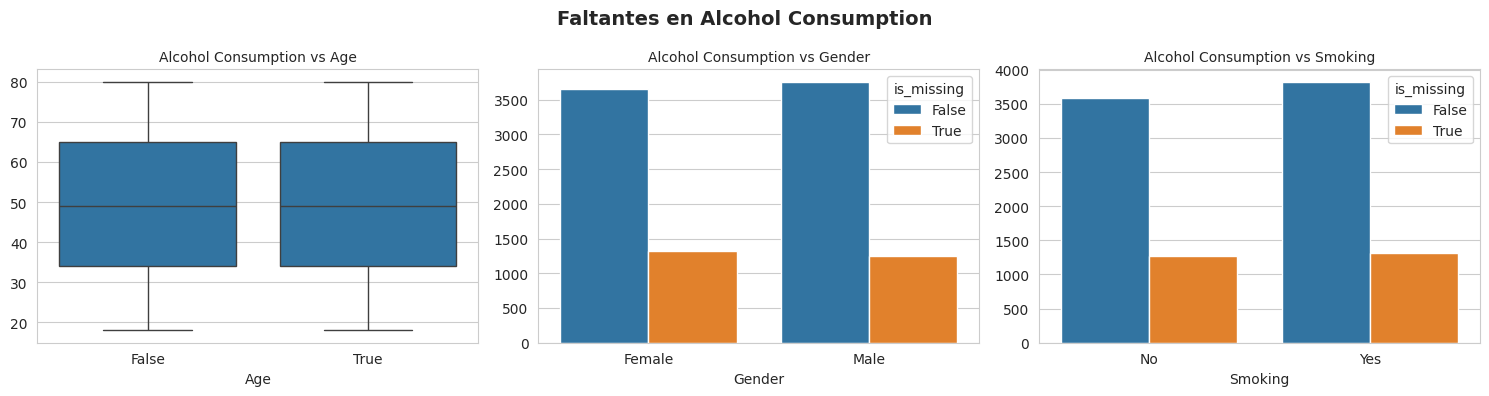

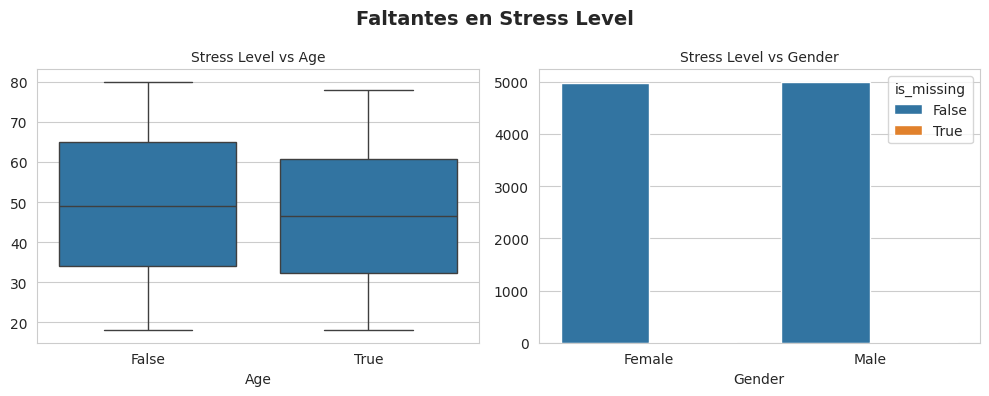

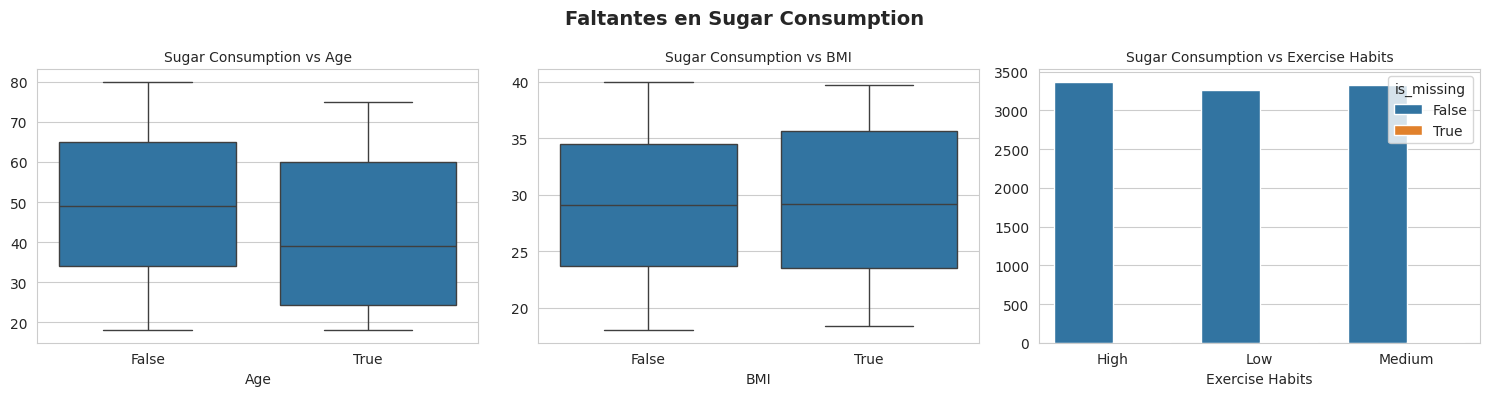

In [ ]:
comparaciones = {
    'Blood Pressure': ['Age', 'Gender', 'High Blood Pressure'],
    'Cholesterol Level': ['Age', 'Exercise Habits', 'Sugar Consumption','BMI','Smoking'],
    'Smoking': ['Age','Gender', 'Stress Level', 'Alcohol Consumption'],
    'Exercise Habits': ['Age', 'Stress Level', 'BMI','Gender','Fasting Blood Sugar','Sleep Hours','Alcohol Consumption'],
    'BMI': ['Age', 'Gender', 'Exercise Habits'],
    'Triglyceride Level': ['Age', 'Cholesterol Level', 'Sugar Consumption'],
    'Fasting Blood Sugar': ['Age', 'Diabetes', 'BMI', 'Sugar Consumption'],
    'CRP Level': ['Age', 'Stress Level','Gender','Low HDL Cholesterol','High LDL Cholesterol','Cholesterol Level'],
    'Homocysteine Level': ['Age', 'Family Heart Disease','Low HDL Cholesterol','High LDL Cholesterol','Cholesterol Level'],
    'Sleep Hours': ['Age', 'Stress Level', 'Gender', 'Exercise Habits', 'Smoking'],
    'Family Heart Disease': ['Age', 'Gender', 'Diabetes'],
    'Diabetes': ['Age', 'BMI', 'Sugar Consumption', 'Gender', 'Smoking'],
    # --
    'High Blood Pressure': ['Age', 'Blood Pressure', 'BMI', 'Gender', 'Blood Pressure'],
    'Low HDL Cholesterol': ['Age', 'BMI'],
    'High LDL Cholesterol': ['Age', 'BMI'],
    'Alcohol Consumption': ['Age', 'Gender', 'Smoking'],
    'Stress Level': ['Age', 'Gender'],
    'Sugar Consumption': ['Age', 'BMI', 'Exercise Habits']
}

for var, related_vars in comparaciones.items():
    df['is_missing'] = df[var].isnull()

    fig, axes = plt.subplots(1, len(related_vars), figsize=(5*len(related_vars), 4))
    fig.suptitle(f'Faltantes en {var}', fontsize=14, fontweight='bold')

    for j, comp in enumerate(related_vars):
        ax = axes[j] if len(related_vars) > 1 else axes
        if df[comp].dtype.name in ['category', 'object']:
            sns.countplot(data=df, x=comp, hue='is_missing', ax=ax)
        else:
            sns.boxplot(data=df, x='is_missing', y=comp, ax=ax)
        ax.set_title(f'{var} vs {comp}', fontsize=10)
        ax.set_xlabel(comp)
        ax.set_ylabel('')

    plt.tight_layout()
    plt.show()



Cantidad de individuos por grupo de edad:
Age_Group
18-29    1675
30-39    1615
40-49    1588
50-59    1550
60-69    1572
70-79    1662
80        160
Name: count, dtype: int64


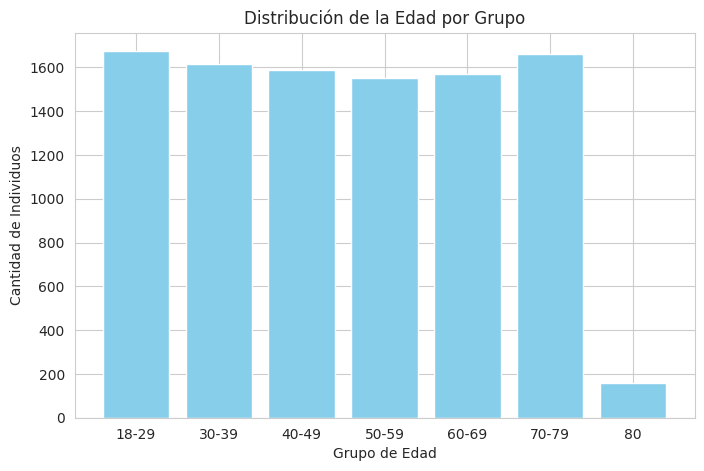

In [ ]:
# Distribución edad

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

age_counts = df['Age_Group'].value_counts().sort_index()

print("Cantidad de individuos por grupo de edad:")
print(age_counts)

plt.figure(figsize=(8,5))
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.title("Distribución de la Edad por Grupo")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Individuos")
plt.show()

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np
import pandas as pd

def analizar_dependencia_faltantes(df, target_var, cond_var, alpha=0.05):
    """
    Evalúa si la falta de datos en 'target_var' depende de los valores observados en 'cond_var' (Patrón MAR vs MCAR).
    Aplica Chi-cuadrado para categóricas y Mann-Whitney U para continuas.

    Args:
        df (pd.DataFrame): DataFrame de trabajo.
        target_var (str): La columna con valores faltantes que se está analizando.
        cond_var (str): La columna condicionante (observada) para la comparación.
        alpha (float): Nivel de significancia (por defecto 0.05).

    Returns:
        dict: Diccionario con 'Prueba', 'Valor P', 'Conclusión' y medianas (si es aplicable).
    """

    is_missing_mask = df[target_var].isnull()
    num_missing = is_missing_mask.sum()

    # Inicialización del diccionario de resultados
    resultado = {
        'Target Faltante': target_var,
        'Condicionante': cond_var,
        'Prueba': '',
        'Valor P': np.nan,
        'Conclusion': 'Datos faltantes insuficientes.'
    }

    if num_missing < 2:
        resultado['Prueba'] = 'N/A'
        return resultado

    p_value = np.nan # Inicializamos p_value aquí

    # --- 1. PRUEBA PARA VARIABLES CATEGÓRICAS (Chi-cuadrado) ---
    if df[cond_var].dtype.name in ['category', 'object', 'bool']:

        contingency_table = pd.crosstab(df[cond_var], is_missing_mask)
        contingency_table = contingency_table.loc[(contingency_table.sum(axis=1) > 0)]
        contingency_table = contingency_table.loc[:, (contingency_table.sum(axis=0) > 0)]

        resultado['Prueba'] = "Chi-cuadrado"
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            resultado['Conclusion'] = "Datos insuficientes para Chi-cuadrado."
            return resultado

        try:
            _, p_value, _, _ = chi2_contingency(contingency_table)
        except ValueError:
            resultado['Conclusion'] = "Error de cálculo."
            return resultado

    # --- 2. PRUEBA PARA VARIABLES CONTINUAS (Mann-Whitney U) ---
    elif df[cond_var].dtype.name in ['float64', 'int64']:

        g1 = df.loc[is_missing_mask, cond_var].replace([np.inf, -np.inf], np.nan).dropna() # Grupo Faltante
        g2 = df.loc[~is_missing_mask, cond_var].replace([np.inf, -np.inf], np.nan).dropna() # Grupo Presente

        resultado['Prueba'] = "Mann-Whitney U"
        if len(g1) < 5 or len(g2) < 5:
            resultado['Conclusion'] = "Datos insuficientes para Mann-Whitney."
            return resultado

        # Compara distribuciones/medianas
        _, p_value = mannwhitneyu(g1, g2, alternative='two-sided')
        resultado['Mediana Faltante'] = round(g1.median(), 2)
        resultado['Mediana Presente'] = round(g2.median(), 2)

    else:
        resultado['Prueba'] = 'N/A'
        resultado['Conclusion'] = f"Tipo de dato '{df[cond_var].dtype.name}' no soportado."
        return resultado

    # 3. Conclusión Final (Se ejecuta SÓLO si p_value fue asignado en 1 o 2)

    # Asigna el valor p redondeado
    resultado['Valor P'] = round(p_value, 5)

    # Determina MAR o MCAR
    if p_value < alpha:
        resultado['Conclusion'] = "MAR (Dependencia significativa)"
    else:
        resultado['Conclusion'] = "MCAR (No hay dependencia significativa)"

    return resultado

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np
import pandas as pd

# (La función analizar_dependencia_faltantes se mantiene igual y debe estar disponible)

def ejecutar_analisis_individual(df, target_var, cond_vars_list, alpha=0.05):
    """
    Ejecuta el análisis de dependencia MAR/MCAR para una sola variable faltante (target_var)
    contra una lista de variables condicionantes (cond_vars_list).

    Args:
        df (pd.DataFrame): DataFrame de trabajo.
        target_var (str): La variable con faltantes a analizar (ej. 'Blood Pressure').
        cond_vars_list (list): La LISTA de variables a comparar (ej. ['Age', 'Gender', 'High Blood Pressure']).
        alpha (float): Nivel de significancia.

    Returns:
        pd.DataFrame: Tabla resumen con el resultado de cada comparación.
    """

    if not isinstance(cond_vars_list, list):
        print("Error: El tercer argumento debe ser una lista de variables a comparar (ej. ['Age', 'Gender']).")
        return pd.DataFrame()

    cond_vars = cond_vars_list
    resultados_dependencia = []

    print(f"--- INICIANDO ANÁLISIS FORMAL para: {target_var} ({df[target_var].isnull().sum()} faltantes) ---")

    for cond_var in cond_vars:
        # Llama a la función que DISCRIMINA la prueba (Chi2 vs MWU)
        # NOTA: La función 'analizar_dependencia_faltantes' DEBE estar definida arriba.
        resultado = analizar_dependencia_faltantes(df, target_var, cond_var, alpha)

        resultados_dependencia.append(resultado)

    # Crea el DataFrame resumen
    df_resultados = pd.DataFrame(resultados_dependencia)

    # Reordena y devuelve las columnas
    cols = ['Target Faltante', 'Condicionante', 'Prueba', 'Valor P', 'Conclusion']
    if 'Mediana Faltante' in df_resultados.columns:
        cols.extend(['Mediana Faltante', 'Mediana Presente'])

    return df_resultados.reindex(columns=cols)

***Blood Pressure***

In [ ]:

df['is_missing'] = df['Blood Pressure'].isnull()

bins = [0, 30, 40, 50, 60, 70, 80, 100]
labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

missing_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing']
    .mean()
    .mul(100)
    .round(2)
)

print(missing_by_age)


Age_Group
<30      0.05
30-39    0.06
40-49    0.25
50-59    0.19
60-69    0.38
70-79    0.24
80+      0.00
Name: is_missing, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Blood Pressure', comparaciones['Blood Pressure'])
# print("Resultados de 'Blood Pressure':")
# print(resultados_bp)

Analizando graficos y resultados se deduce tipo MAR.
- distribucion mas uniforme (esta mas adelante). bajo porcentaje de faltante. imputacion por mediana

***Cholesterol Level***

In [ ]:
df['is_missing'] = df['Cholesterol Level'].isnull()

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

missing_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing']
    .mean()
    .mul(100)
    .round(2)
)

print(missing_by_age)



Age_Group
18-29    0.24
30-39    0.25
40-49    0.25
50-59    0.52
60-69    0.19
70-79    0.36
80       0.62
Name: is_missing, dtype: float64


NIVELES IMC: https://www.cun.es/escuela-salud/indice-masa-corporal#:~:text=Normal%20(18.5%2D24.9),Obesidad%20(30%20o%20m%C3%A1s).

In [ ]:
df['is_missing'] = df['Cholesterol Level'].isnull()
max_bmi = df['BMI'].max()
bins = [0, 18.5, 25, 30, max_bmi + 0.01]

labels = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']

df['BMI_Group'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False)

missing_by_bmi = df.groupby('BMI_Group', observed=False)['is_missing'].mean().mul(100).round(2)

print("Porcentaje de faltantes en 'Cholesterol Level' por grupo de BMI:")
print(missing_by_bmi)

Porcentaje de faltantes en 'Cholesterol Level' por grupo de BMI:
BMI_Group
Bajo peso    0.86
Normal       0.32
Sobrepeso    0.38
Obesidad     0.22
Name: is_missing, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Cholesterol Level', comparaciones['Cholesterol Level'])
# print("Resultados de 'Cholesterol Level':")
# print(resultados_bp)

observando graficos y pruebas, se concluye tipo MAR (en cuanto a edad hay un porcentaje alto de faltantes en el ultimo grupo).
imputacion: knn

***Smoking***

In [ ]:

df['is_missing_smoking'] = df['Smoking'].isnull()

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
missing_by_age_smoking = (
    df.groupby('Age_Group', observed=False)['is_missing_smoking']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'Smoking' por grupo de edad:")
print(missing_by_age_smoking)


Porcentaje de faltantes en 'Smoking' por grupo de edad:
Age_Group
18-29    0.30
30-39    0.31
40-49    0.38
50-59    0.26
60-69    0.06
70-79    0.18
80       0.62
Name: is_missing_smoking, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Smoking', comparaciones['Smoking'])
# print("Resultados de 'Smoking':")
# print(resultados_bp)

observando graficos y prueba con respecto a edad, se ve que para el rango de mayor edad existen muchos faltantes. tipo MAR
imputacion: moda por grupo de edad

***Exercise Habits***

In [ ]:

df['is_missing_exercise'] = df['Exercise Habits'].isnull()

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
missing_by_age_smoking = (
    df.groupby('Age_Group', observed=False)['is_missing_exercise']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'Exercise Habits' por grupo de edad:")
print(missing_by_age_smoking)

Porcentaje de faltantes en 'Exercise Habits' por grupo de edad:
Age_Group
18-29    0.24
30-39    0.31
40-49    0.38
50-59    0.19
60-69    0.32
70-79    0.12
80       0.00
Name: is_missing_exercise, dtype: float64


In [ ]:
resultados_bp = ejecutar_analisis_individual(df, 'Exercise Habits', comparaciones['Exercise Habits'])
print("Resultados de 'Exercise Habits':")
print(resultados_bp)

observando graficos y pruebas, se concluye que la variable no depende de otras presentes. tipo MCAR
imputacion: moda

***BMI***

In [ ]:
bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)


df['is_missing_bmi'] = df['BMI'].isnull()

missing_percent_bmi_by_age = df.groupby('Age_Group', observed=False)['is_missing_bmi'].mean()

print("Porcentaje de faltantes en 'BMI' por grupo de edad:")
print((missing_percent_bmi_by_age * 100).round(2))


Porcentaje de faltantes en 'BMI' por grupo de edad:
Age_Group
18-29    0.12
30-39    0.31
40-49    0.19
50-59    0.26
60-69    0.19
70-79    0.24
80       0.62
Name: is_missing_bmi, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'BMI', comparaciones['BMI'])
# print("Resultados de 'BMI':")
# print(resultados_bp)

dependencia con edad (gran porcentaje de faltantes en rango de edad mas alto). tipo MAR
- imputacion: KNN

***Triglyceride Level***

In [ ]:

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df['is_missing_triglyceride'] = df['Triglyceride Level'].isnull()

missing_percent_triglyceride_by_age = df.groupby('Age_Group',observed=False)['is_missing_triglyceride'].mean()

print("Porcentaje de faltantes en 'Triglyceride Level' por grupo de edad:")
print((missing_percent_triglyceride_by_age * 100).round(2))


Porcentaje de faltantes en 'Triglyceride Level' por grupo de edad:
Age_Group
18-29    0.18
30-39    0.50
40-49    0.19
50-59    0.26
60-69    0.25
70-79    0.24
80       0.00
Name: is_missing_triglyceride, dtype: float64


In [ ]:
resultados_bp = ejecutar_analisis_individual(df, 'Triglyceride Level', comparaciones['Triglyceride Level'])
print("Resultados de 'Triglyceride Level':")
print(resultados_bp)

MCAR?

***Fasting Blood Sugar***

In [ ]:
bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)


df['is_missing_fbs'] = df['Fasting Blood Sugar'].isnull()

missing_percent_fbs_by_age = df.groupby('Age_Group', observed=False)['is_missing_fbs'].mean()

print("Porcentaje de faltantes en 'Fasting Blood Sugar' por grupo de edad:")
print((missing_percent_fbs_by_age * 100).round(2))


Porcentaje de faltantes en 'Fasting Blood Sugar' por grupo de edad:
Age_Group
18-29    0.18
30-39    0.25
40-49    0.06
50-59    0.45
60-69    0.25
70-79    0.12
80       0.62
Name: is_missing_fbs, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Fasting Blood Sugar', comparaciones['Fasting Blood Sugar'])
# print("Resultados de 'Fasting Blood Sugar':")
# print(resultados_bp)

tipo MAR.
- imputacion: knn

***CRP Level***

In [ ]:
df['is_missing_crp'] = df['CRP Level'].isnull()

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

missing_percent_crp_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing_crp']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'CRP Level' por grupo de edad:")
print(missing_percent_crp_by_age)


Porcentaje de faltantes en 'CRP Level' por grupo de edad:
Age_Group
18-29    0.24
30-39    0.43
40-49    0.31
50-59    0.26
60-69    0.13
70-79    0.18
80       0.00
Name: is_missing_crp, dtype: float64


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'CRP Level', comparaciones['CRP Level'])
# print("Resultados de 'CRP Level':")
# print(resultados_bp)

tipo MCAR. imputacion: mediana

***Homocysteine Level***

In [ ]:
df['is_missing_homocysteine'] = df['Homocysteine Level'].isnull()

bins = [18, 29, 39, 49, 59, 69, 79, 80]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

missing_percent_homocysteine_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing_homocysteine']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'Homocysteine Level' por grupo de edad:")
print(missing_percent_homocysteine_by_age)


Porcentaje de faltantes en 'Homocysteine Level' por grupo de edad:
Age_Group
18-29    0.12
30-39    0.19
40-49    0.31
50-59    0.39
60-69    0.13
70-79    0.12
80       0.00
Name: is_missing_homocysteine, dtype: float64


In [ ]:
bins = [150, 180, 210, 240, 270, 300]
labels = ['150-180', '180-210', '210-240', '240-270', '270-300']

df['Cholesterol_Range'] = pd.cut(df['Cholesterol Level'], bins=bins, labels=labels, right=False)
result = df.groupby('Cholesterol_Range',observed=True)['Homocysteine Level'].apply(lambda x: x.isna().mean()).reset_index()

result.columns = ['Cholesterol_Range', 'Proportion_Missing_Homocysteine']

print(result)

  Cholesterol_Range  Proportion_Missing_Homocysteine
0           150-180                         0.001029
1           180-210                         0.001496
2           210-240                         0.002573
3           240-270                         0.003486
4           270-300                         0.001499


tipo MAR?

***Sleep Hours***

In [ ]:
# df['is_missing_sleep'] = df['Sleep Hours'].isnull()
# bins = [18, 29, 39, 49, 59, 69, 79, 80]
# labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80']
# df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# missing_percent_sleep_by_age = (
#     df.groupby('Age_Group', observed=False)['is_missing_sleep']
#     .mean()
#     .mul(100)
#     .round(2)
# )

# print("Porcentaje de faltantes en 'Sleep Hours' por grupo de edad:")
# print(missing_percent_sleep_by_age)


Porcentaje de faltantes en 'Sleep Hours' por grupo de edad:
Age_Group
18-29    0.30
30-39    0.19
40-49    0.19
50-59    0.19
60-69    0.45
70-79    0.18
80       0.00
Name: is_missing_sleep, dtype: float64


tipo mcar

In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Sleep Hours', comparaciones['Sleep Hours'])
# print("Resultados de 'Sleep Hours':")
# print(resultados_bp)

--- INICIANDO ANÁLISIS FORMAL para: Sleep Hours (25 faltantes) ---
Resultados de 'Sleep Hours':
  Target Faltante    Condicionante          Prueba  Valor P  \
0     Sleep Hours              Age  Mann-Whitney U  0.78110   
1     Sleep Hours     Stress Level    Chi-cuadrado  0.04494   
2     Sleep Hours           Gender    Chi-cuadrado  0.23445   
3     Sleep Hours  Exercise Habits    Chi-cuadrado  0.55843   
4     Sleep Hours          Smoking    Chi-cuadrado  0.08209   

                                Conclusion  Mediana Faltante  Mediana Presente  
0  MCAR (No hay dependencia significativa)              50.0              49.0  
1          MAR (Dependencia significativa)               NaN               NaN  
2  MCAR (No hay dependencia significativa)               NaN               NaN  
3  MCAR (No hay dependencia significativa)               NaN               NaN  
4  MCAR (No hay dependencia significativa)               NaN               NaN  


***Family Heart Disease***

In [ ]:
df['is_missing_fhd'] = df['Family Heart Disease'].isnull()

bins = [18, 30, 40, 50, 60, 70, 80, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

missing_percent_fhd_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing_fhd']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'Family Heart Disease' por grupo de edad:")
print(missing_percent_fhd_by_age)


In [ ]:
# resultados_bp = ejecutar_analisis_individual(df, 'Family Heart Disease', comparaciones['Family Heart Disease'])
# print("Resultados de 'Family Heart Disease':")
# print(resultados_bp)

--- INICIANDO ANÁLISIS FORMAL para: Family Heart Disease (21 faltantes) ---
Resultados de 'Family Heart Disease':
        Target Faltante Condicionante          Prueba  Valor P  \
0  Family Heart Disease           Age  Mann-Whitney U  0.49187   
1  Family Heart Disease        Gender    Chi-cuadrado  0.38852   
2  Family Heart Disease      Diabetes    Chi-cuadrado  0.68435   

                                Conclusion  Mediana Faltante  Mediana Presente  
0  MCAR (No hay dependencia significativa)              43.0              49.0  
1  MCAR (No hay dependencia significativa)               NaN               NaN  
2  MCAR (No hay dependencia significativa)               NaN               NaN  


tipo MAR?

***Diabetes***

In [ ]:
df['is_missing'] = df['Diabetes'].isnull()
max_bmi = df['BMI'].max()
bins = [0, 18.5, 25, 30, max_bmi + 0.01]

labels = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']

df['BMI_Group'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False)

missing_by_bmi = df.groupby('BMI_Group', observed=False)['is_missing'].mean().mul(100).round(2)

print("Porcentaje de faltantes en 'Diabetes' por grupo de BMI:")
print(missing_by_bmi)

Porcentaje de faltantes en 'Diabetes' por grupo de BMI:
BMI_Group
Bajo peso    0.43
Normal       0.35
Sobrepeso    0.13
Obesidad     0.35
Name: is_missing, dtype: float64


In [ ]:
df['is_missing_fhd'] = df['Diabetes'].isnull()

bins = [18, 30, 40, 50, 60, 70, 80, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

missing_percent_fhd_by_age = (
    df.groupby('Age_Group', observed=False)['is_missing_fhd']
    .mean()
    .mul(100)
    .round(2)
)

print("Porcentaje de faltantes en 'Diabetes' por grupo de edad:")
print(missing_percent_fhd_by_age)


Porcentaje de faltantes en 'Diabetes' por grupo de edad:
Age_Group
18-29    0.27
30-39    0.19
40-49    0.44
50-59    0.19
60-69    0.25
70-79    0.48
80+      0.00
Name: is_missing_fhd, dtype: float64


tipo mar. moda

| Variable               | Tipo         | % faltantes | Tipo de faltante | Imputación           |
|------------------------|--------------|-------------|-----------------|--------------------|
| Age                    | Numérica     | 0.29%       |                 |                      |
| Gender                 | Categórica   | 0.19%       |                 |                      |
| Blood Pressure         | Numérica     | 0.19%       |   MAR              | Mediana              |
| Cholesterol Level      | Numérica     | 0.30%       |   MAR              | KNN                  |
| Exercise Habits        | Categórica   | 0.25%       |   MCAR              |        Moda              |
| Smoking                | Categórica   | 0.25%       |    MAR             | Moda por edad        |
| Family Heart Disease   | Categórica   | 0.21%       |                 |                      |
| Diabetes               | Categórica   | 0.30%       |        MAR         |          Moda            |
| BMI                    | Numérica     | 0.22%       |     MAR            |         KNN             |
| High Blood Pressure    | Categórica   | 0.26%       |                 |                      |
| Low HDL Cholesterol    | Categórica   | 0.25%       |                 |                      |
| High LDL Cholesterol   | Categórica   | 0.26%       |                 |                      |
| Alcohol Consumption    | Categórica   | 25.86%      |                 |                      |
| Stress Level           | Categórica   | 0.22%       |                 |                      |
| Sleep Hours            | Numérica     | 0.25%       |      MCAR           |                      |
| Sugar Consumption      | Categórica   | 0.30%       |                 |                      |
| Triglyceride Level     | Numérica     | 0.26%       |                 |                      |
| Fasting Blood Sugar    | Numérica     | 0.22%       |      MAR           |      KNN                |
| CRP Level              | Numérica     | 0.26%       |    MCAR             |      Mediana                |
| Homocysteine Level     | Numérica     | 0.20%       |    MCAR             |         Mediana             |





- ------------------

In [ ]:
msno.dendrogram(df, figsize=(12, 6), fontsize=10)

#### **Análisis de valores atípicos**

Valores presentes en variables categóricas

In [ ]:
var_categoricas = ['Gender','Exercise Habits','Smoking','Family Heart Disease', 'Diabetes','High Blood Pressure','High LDL Cholesterol','Low HDL Cholesterol','Alcohol Consumption','Stress Level','Sugar Consumption','Heart Disease Status']

pd.DataFrame({col: [df[col].unique()] for col in var_categoricas}).T.rename(columns={0: 'Valores únicos'})

,Valores únicos
Gender,"['Male', 'Female', NaN] Categories (2, object)..."
Exercise Habits,"['High', 'Low', 'Medium', NaN] Categories (3, ..."
Smoking,"['Yes', 'No', NaN] Categories (2, object): ['N..."
Family Heart Disease,"['Yes', 'No', NaN] Categories (2, object): ['N..."
Diabetes,"['No', 'Yes', NaN] Categories (2, object): ['N..."
High Blood Pressure,"['Yes', 'No', NaN] Categories (2, object): ['N..."
High LDL Cholesterol,"['No', 'Yes', NaN] Categories (2, object): ['N..."
Low HDL Cholesterol,"['Yes', 'No', NaN] Categories (2, object): ['N..."
Alcohol Consumption,"['High', 'Medium', 'Low', NaN] Categories (3, ..."
Stress Level,"['Medium', 'High', 'Low', NaN] Categories (3, ..."


No se observan valores extraños en ninguna de las variables categóricas.

In [ ]:
# columnas_numericas = df.select_dtypes(include='number').columns.to_list()
# for col in columnas_numericas:
#     plt.figure(figsize=(3, 2))
#     sns.boxplot(x=df[col])
#     plt.title(f"Boxplot de {col}")
#     plt.tight_layout()
#     plt.show()

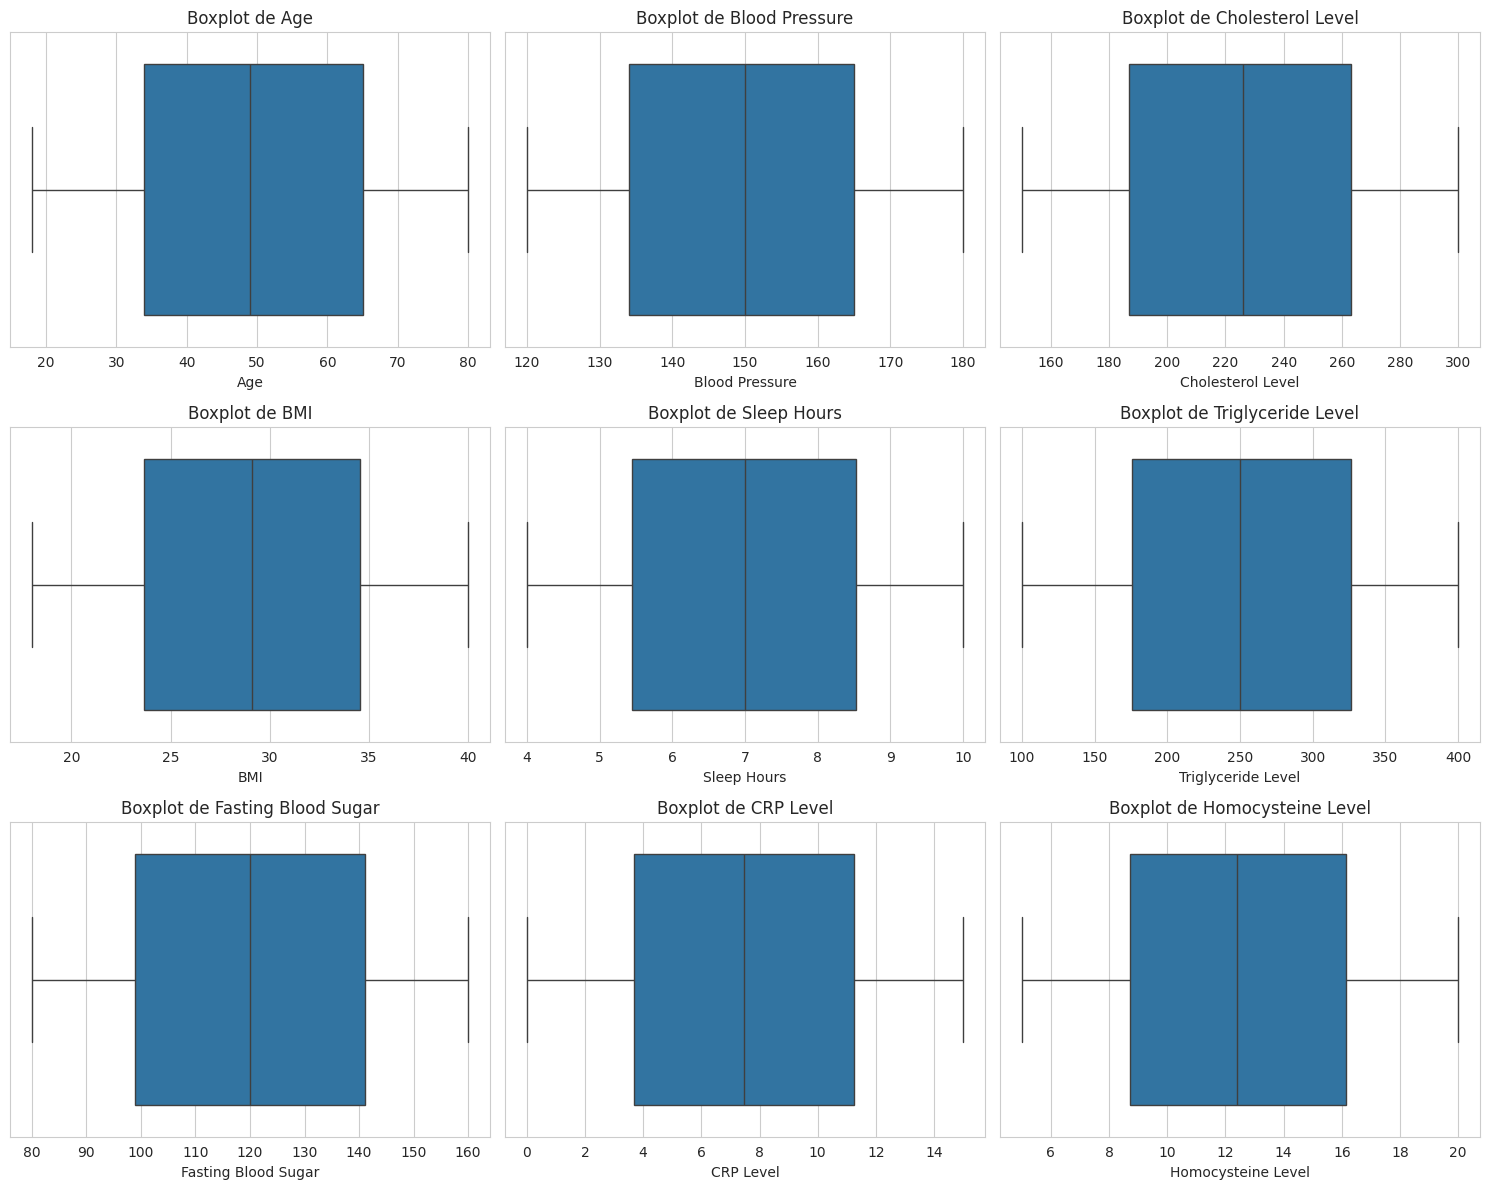

In [ ]:
columnas_numericas = df.select_dtypes(include='number').columns.to_list()

# Parámetros de layout
n_cols = 3  # Número de gráficos por fila
n_plots = len(columnas_numericas)
n_rows = math.ceil(n_plots / n_cols)

# Crear figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Aplanar los ejes (por si hay más de una fila)
axes = axes.flatten()

# Dibujar cada boxplot
for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

# Ocultar los ejes vacíos (si hay más espacios que columnas)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,8))
sns.boxplot(df)
plt.show()

In [ ]:
# columnas_numericas = df.select_dtypes(include='number').columns.to_list()

# outliers_detectados = {}

# for col in columnas_numericas:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     limite_inferior = Q1 - 1.5 * IQR
#     limite_superior = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

#     outliers_detectados[col] = {
#         'cantidad': outliers.shape[0],
#         'porcentaje': 100 * outliers.shape[0] / df.shape[0]
#     }

# # Mostrar resumen
# for col, info in outliers_detectados.items():
#     print(f"{col}: {info['cantidad']} outliers ({info['porcentaje']:.2f}%)")

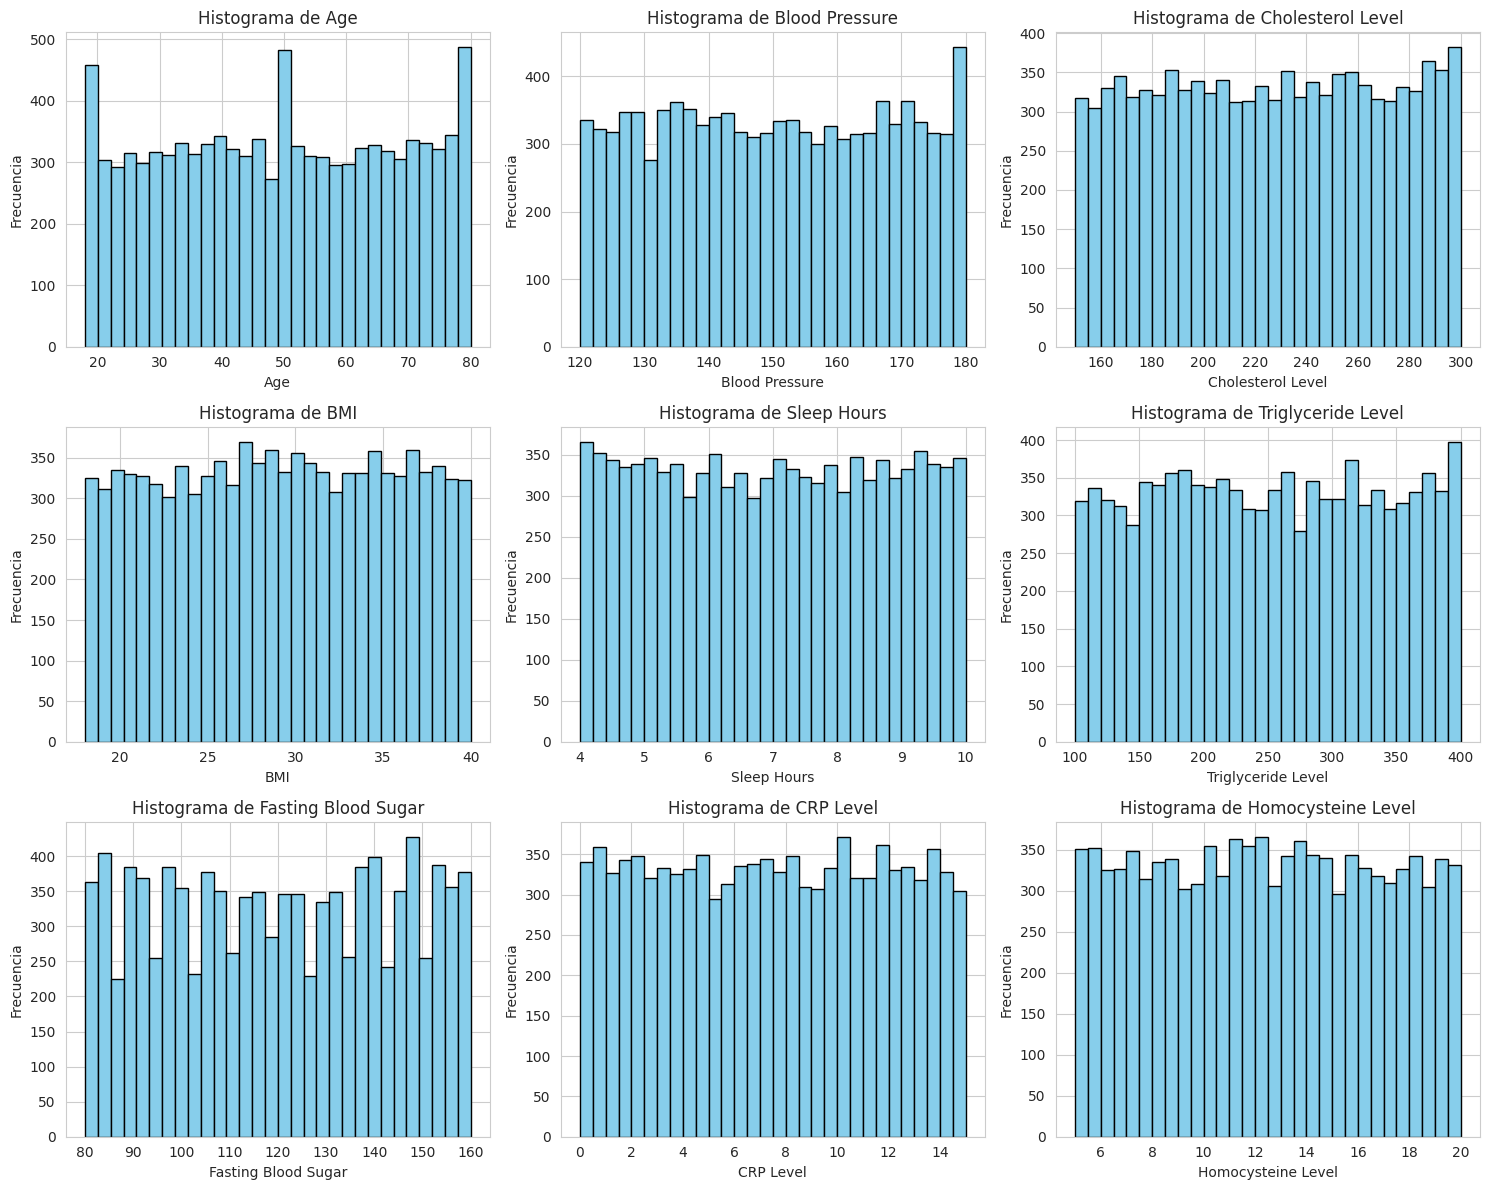

In [ ]:

# Lista de columnas numéricas
columnas_numericas = df.select_dtypes(include='number').columns.to_list()

n_cols = 3
n_plots = len(columnas_numericas)
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]
for i, col in enumerate(columnas_numericas):
    axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Histograma de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Quitar ejes vacíos si los hay
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### **Distribuciones**

Age: La distribución de la edad muestra una forma relativamente uniforme a lo largo de los diferentes rangos etarios, con picos en ciertos intervalos, como entre los 40-50 años y 60-70 años. Esto indica que la población está bien distribuida entre los diferentes grupos de edad, sin sesgos significativos hacia un grupo específico.

2. Distribución de la Presión Arterial (Blood Pressure)

La distribución de la presión arterial es también relativamente uniforme con ligeros picos en valores bajos, especialmente en el rango de 120-130 mmHg. Esto podría indicar una población general sin una clara tendencia hacia valores extremadamente altos o bajos, aunque algunos valores más altos también están presentes, lo que es común en poblaciones con hipertensión.

3. Distribución del Nivel de Colesterol (Cholesterol Level)

El nivel de colesterol presenta una distribución bastante uniforme, aunque se observa una ligera concentración en valores más altos (cercanos a 300 mg/dL). Esta distribución sugiere que un número significativo de la población podría estar en riesgo de dislipidemia o trastornos relacionados con el colesterol.

4. Distribución del Índice de Masa Corporal (BMI)

La distribución del índice de masa corporal (IMC) es relativamente uniforme con algunos picos en los rangos de 25 a 30, lo que sugiere una tendencia hacia el sobrepeso en algunos individuos. Esta distribución es común en poblaciones con prevalencia de sobrepeso o condiciones relacionadas, como obesidad.

5. Distribución de las Horas de Sueño (Sleep Hours)

Las horas de sueño siguen una distribución bastante equilibrada, con un mayor número de personas durmiendo entre 6 y 8 horas. Esto es consistente con los hábitos de sueño recomendados para la mayoría de los adultos, lo que indica una distribución saludable en términos de la cantidad de descanso.

6. Distribución de los Niveles de Triglicéridos (Triglyceride Level)

La distribución de los niveles de triglicéridos es bastante uniforme, aunque se observa un pequeño sesgo hacia los valores más altos (cercanos a 300 mg/dL). Esto puede reflejar una tendencia a la prevalencia de niveles elevados de triglicéridos en la población, lo que es común en estudios relacionados con factores de riesgo cardiovascular.

7. Distribución de la Glucosa en Ayunas (Fasting Blood Sugar)

La distribución de la glucosa en ayunas muestra una ligera concentración en los valores entre 100-120 mg/dL, lo que podría sugerir que un número significativo de individuos se encuentra en un rango de riesgo para prediabetes. La distribución general es bastante equilibrada, lo que es común en poblaciones de adultos mayores o personas en riesgo.

8. Distribución del Nivel de Proteína C Reactiva (CRP Level)

La distribución de la proteína C reactiva (PCR) muestra una tendencia hacia valores bajos, lo cual es común en personas saludables. Sin embargo, la ligera dispersión en la distribución refleja que algunos individuos podrían estar experimentando niveles elevados de inflamación, lo que es relevante para estudios cardiovasculares.

9. Distribución del Nivel de Homocisteína (Homocysteine Level)

La distribución del nivel de homocisteína es relativamente uniforme, con una ligera dispersión. Esto indica que la mayoría de los individuos tienen niveles dentro de un rango normal, aunque la homocisteína es un marcador importante que puede estar elevado en algunas personas con riesgos cardiovasculares.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      9971 non-null   float64 
 1   Gender                   9981 non-null   category
 2   Blood Pressure           9981 non-null   float64 
 3   Cholesterol Level        9970 non-null   float64 
 4   Exercise Habits          9975 non-null   category
 5   Smoking                  9975 non-null   category
 6   Family Heart Disease     9979 non-null   category
 7   Diabetes                 9970 non-null   category
 8   BMI                      9978 non-null   float64 
 9   High Blood Pressure      9974 non-null   category
 10  Low HDL Cholesterol      9975 non-null   category
 11  High LDL Cholesterol     9974 non-null   category
 12  Alcohol Consumption      7414 non-null   category
 13  Stress Level             9978 non-null   category
 14  Sleep H

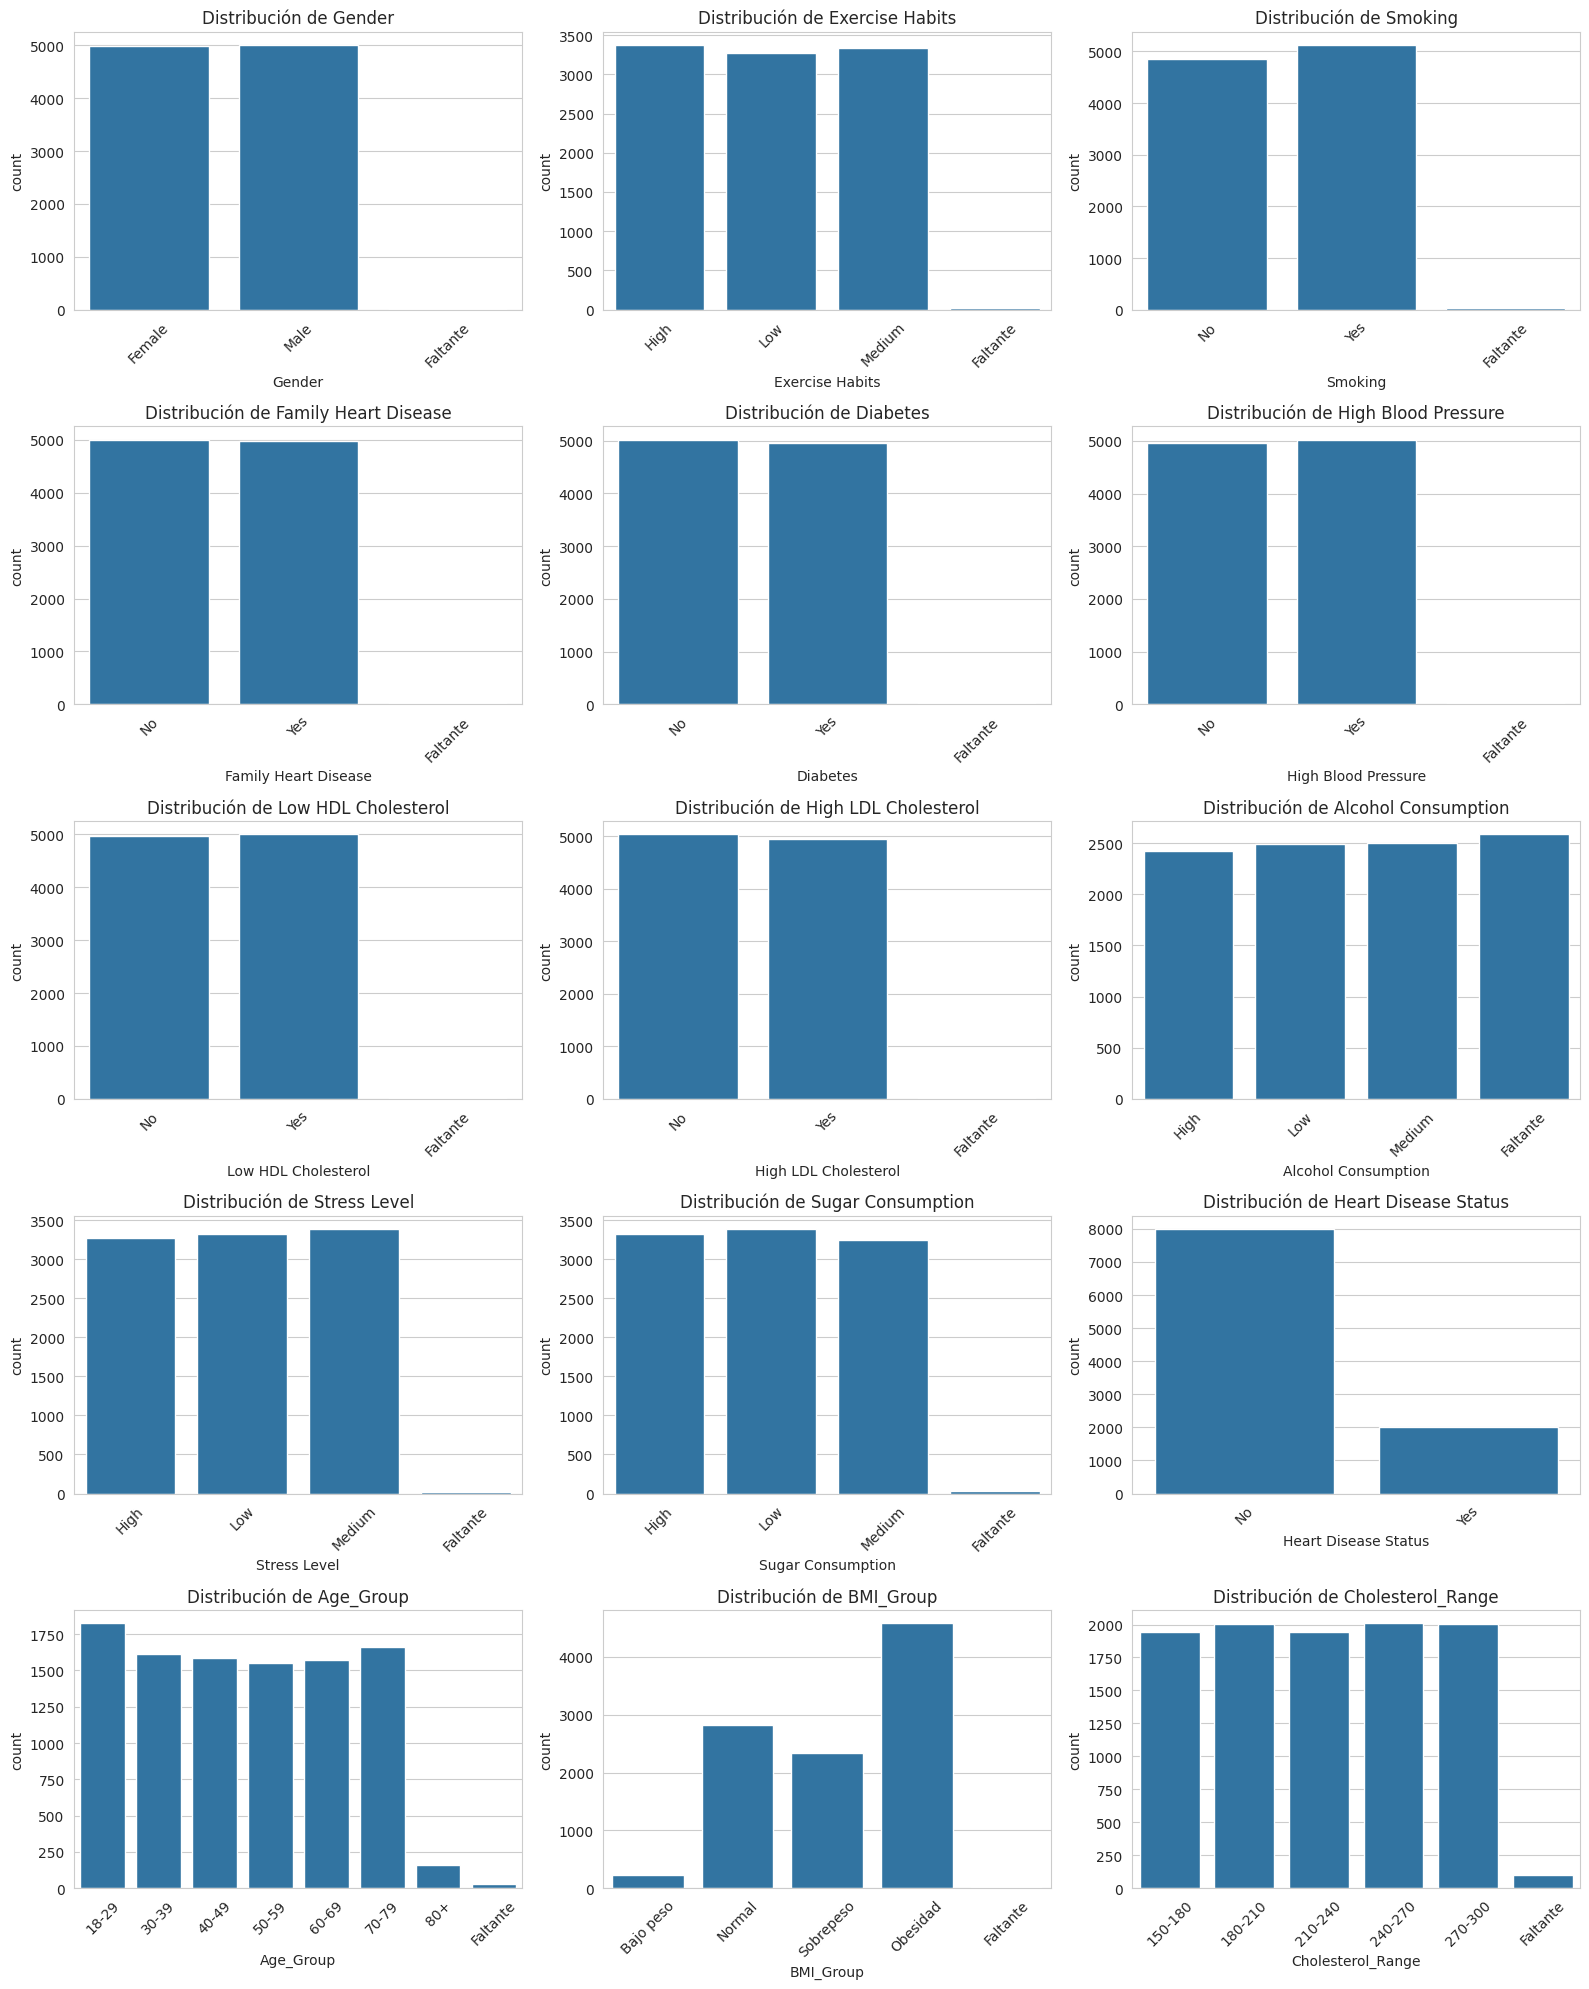

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

n = len(cat_cols)
n_rows = (n // 3) + (n % 3 > 0)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df.copy()

    if isinstance(data[col].dtype, pd.CategoricalDtype):
        data[col] = data[col].cat.add_categories(['Faltante']).fillna('Faltante')
    else:
        data[col] = data[col].fillna('Faltante')

    sns.countplot(data=data, x=col, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos sobrantes
if len(cat_cols) < len(axes):
    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

